# Details of MY Dataset Framingham.csv

1. Gender : Tells person is Male Or Female but in My dataset my column name is Male so i rename it into Gender.
2. Age : tells the Person age.
3. Education : Tells the Person education. It has 4 values.

    | Value  | Meaning              |
    | -----  | -------------------- |
    | 1.0    | High School se kam   |
    | 2.0    | High School graduate |
    | 3.0    | Some College         |
    | 4.0    | College graduate     |

education doesn't play much Role in TenYearCHD so when I formed Model their is very high chance of droping it.

4. currentSmoker : Tells person currently smoke or not. It has 2 value
    0 = Non-Smoker, 1 = Smoker
Smoking CHD ka major risk factor hai.

5. cigsPerDay : Tells how much cigratte person smoke in a day.

6. BPMeds(Blood pressure medication) : Tells Whether Person take BP medicine or not. It has 2 values
    | Value | Meaning |
    | ----- | ------- |
    | 0     | No      |
    | 1     | Yes     |
Jin logon ko high BP hota hai, wo BP meds lete hain → indicator of chronic BP issues → CHD risk link.

7. prevalentStroke : Tells whether Person suffer Stroke in past or not. it ths 2 value 
    | Value | Meaning            |
    | ----- | ------------------ |
    | 0     | No stroke history  |
    | 1     | Stroke in the past |
Past stroke = Very high risk of cardiovascular disease.

8. prevalentHyp(prevalent Hypertension) : Tells whether person suffer prevalent Hypertension (High Blood Pressure) or not.
    | Value | Meaning              |
    | ----- | -------------------- |
    | 0     | No Hypertension      |
    | 1     | Hypertension present |
High BP → CHD ka major risk factor.

9. diabetes : Tells Person suffer from Diabetes or not. it has 2 value
    | Value | Meaning |
    | ----- | ------- |
    | 0     | No      |
    | 1     | Yes     |
Diabetic patients me CHD risk bohot zyada hota hai.

10. totChol : Tells Person Cholestrol
High cholesterol → artery blockage → CHD risk high.

11. sysBP : Systolic Blood Pressure (Upper number)
Heart pumping ke waqt pressure.

12. diaBP : Diastolic Blood Pressure (Lower number)
Heart rest ke waqt pressure.

High BP (sysBP / diaBP) = Strong predictor of CHD.

13. BMI(Body Mass Index) : Weight / Height**2 (where, Weight : Kg & Height : M)
High BMI = Obesity → CHD risk.

14. heartRate : Resting heart rate (beats per minute)
High resting HR → stress on heart → CHD risk factor.

15. glucose : Blood glucose level
High glucose → diabetes link → CHD risk.

# Target Column

TenYearCHD : Ten Year Chronic Heart Diseases
0 = No risk, 1 = CHD likely within 10 years


# Goal :- we Want to predict whether person suffer Heart disease within 10 years or not.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("framingham.csv")

In [3]:
df.shape

(4240, 16)

In [4]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [5]:
df.tail()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0
4239,0,39,3.0,1,30.0,0.0,0,0,0,196.0,133.0,86.0,20.91,85.0,80.0,0


In [6]:
df.sample(1)

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
1786,0,54,1.0,0,0.0,0.0,0,1,0,293.0,132.0,84.0,26.81,80.0,NaN,0


# Getting Some Basic Info From The Data

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [8]:
df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [9]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4135.000000,4240.000000,4211.000000,4187.000000,4240.000000,4240.000000,4240.000000,4190.000000,4240.000000,4240.000000,4221.000000,4239.000000,3852.000000,4240.000000
mean,0.429245,49.580189,1.979444,0.494104,9.005937,0.029615,0.005896,0.310613,0.025708,236.699523,132.354599,82.897759,25.800801,75.878981,81.963655,0.151887
std,0.495027,8.572942,1.019791,0.500024,11.922462,0.169544,0.076569,0.462799,0.158280,44.591284,22.033300,11.910394,4.079840,12.025348,23.954335,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,90.000000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


In [10]:
df.columns

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='object')

In [11]:
eda_df = df.copy()

In [12]:
eda_df

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0


# Lets Start The Univariant Analysis on Numeical Column.

Numerical columns :- age, totChol, sysBP, diaBP, BMI, heartRate, glucose.

# Age Column

conclusion : 
- Mean Age : 49.5 and Median Age : 49
- age is almost normally distributed but if we remain precised it is liitle bit skewed.
- Their is no Outliers in my age column.

In [13]:
eda_df['age']

0       39
1       46
2       48
3       61
4       46
        ..
4235    48
4236    44
4237    52
4238    40
4239    39
Name: age, Length: 4240, dtype: int64

In [14]:
eda_df['age'].describe()

count    4240.000000
mean       49.580189
std         8.572942
min        32.000000
25%        42.000000
50%        49.000000
75%        56.000000
max        70.000000
Name: age, dtype: float64

<Axes: xlabel='age', ylabel='Count'>

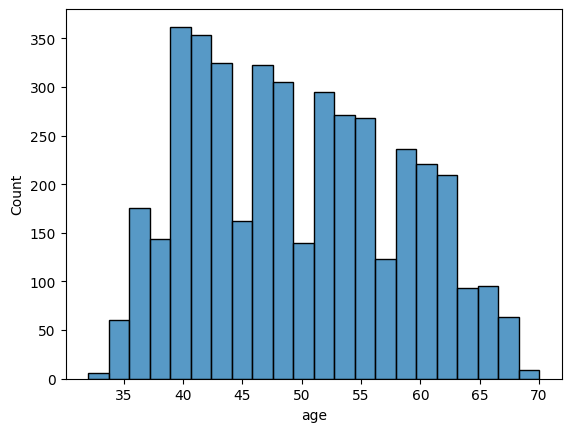

In [15]:
sns.histplot(eda_df['age'])

<Axes: xlabel='age', ylabel='Density'>

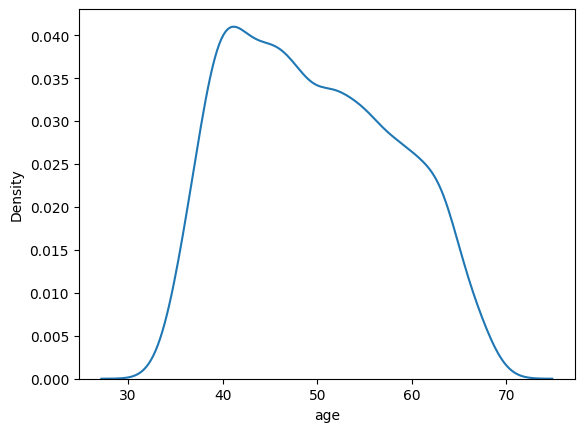

In [16]:
sns.kdeplot(eda_df['age'])

<Axes: ylabel='age'>

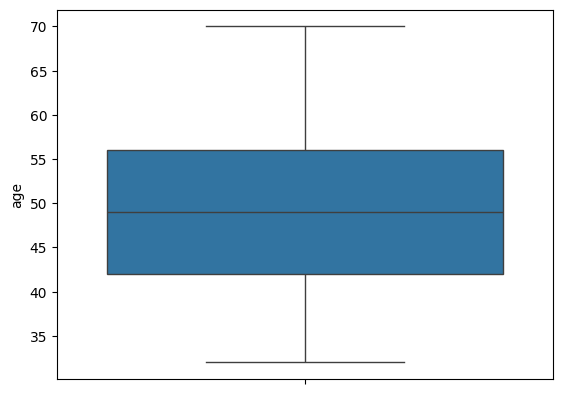

In [17]:
sns.boxplot(eda_df['age'])

In [18]:
eda_df['age'].isnull().sum()

np.int64(0)

In [19]:
eda_df['age'].skew()

np.float64(0.22886703381211243)

# so we do this on all numerical column so we make a helper function to perform things

In [20]:
def univariate_analysis(df, column_name):
    """
    Perform univariate analysis for a given numerical column.
    Shows:
      1. Summary statistics
      2. Null count
      3. Skewness
      4. Histogram
      5. KDE Plot
      6. Boxplot
    """
    print(f"📊 Univariate Analysis for: {column_name}")
    print("="*60)
    
    # 1️⃣ Basic Info
    print("\n➡️ Summary Statistics:")
    print(df[column_name].describe())
    
    # 2️⃣ Missing values
    null_count = df[column_name].isnull().sum()
    print(f"\n🚫 Missing Values: {null_count}")
    
    # 2️⃣ missing values in percentage
    null_percent = df[column_name].isnull().mean()*100
    print(f"\n🚫 Missing Values in percentage: {null_percent:.3f}")
    
    # 3️⃣ Skewness
    skew_value = df[column_name].skew()
    print(f"\n📈 Skewness: {skew_value:.3f}")
    
    # 4️⃣ Plotting
    fig, axes = plt.subplots(1, 3, figsize=(22, 8))
    
    # Histogram
    sns.histplot(df[column_name], kde=False, ax=axes[0], color='blue')
    axes[0].set_title(f"Histogram of {column_name}")
    
    # KDE Plot
    sns.kdeplot(df[column_name], ax=axes[1], color='orange')
    axes[1].set_title(f"KDE Plot of {column_name}")
    
    # Boxplot
    sns.boxplot(x=df[column_name], ax=axes[2], color='lightgreen')
    axes[2].set_title(f"Boxplot of {column_name}")
    
    plt.tight_layout()
    plt.show()

# Total Cholestrol

conclusion : 
- Mean : 236.69 and Median : 234
- Their is 50 missing values and In percentage it is 1.179
- it is right skewed data.
- it contains Outliers as well.

📊 Univariate Analysis for: totChol

➡️ Summary Statistics:
count    4190.000000
mean      236.699523
std        44.591284
min       107.000000
25%       206.000000
50%       234.000000
75%       263.000000
max       696.000000
Name: totChol, dtype: float64

🚫 Missing Values: 50

🚫 Missing Values in percentage: 1.179

📈 Skewness: 0.872


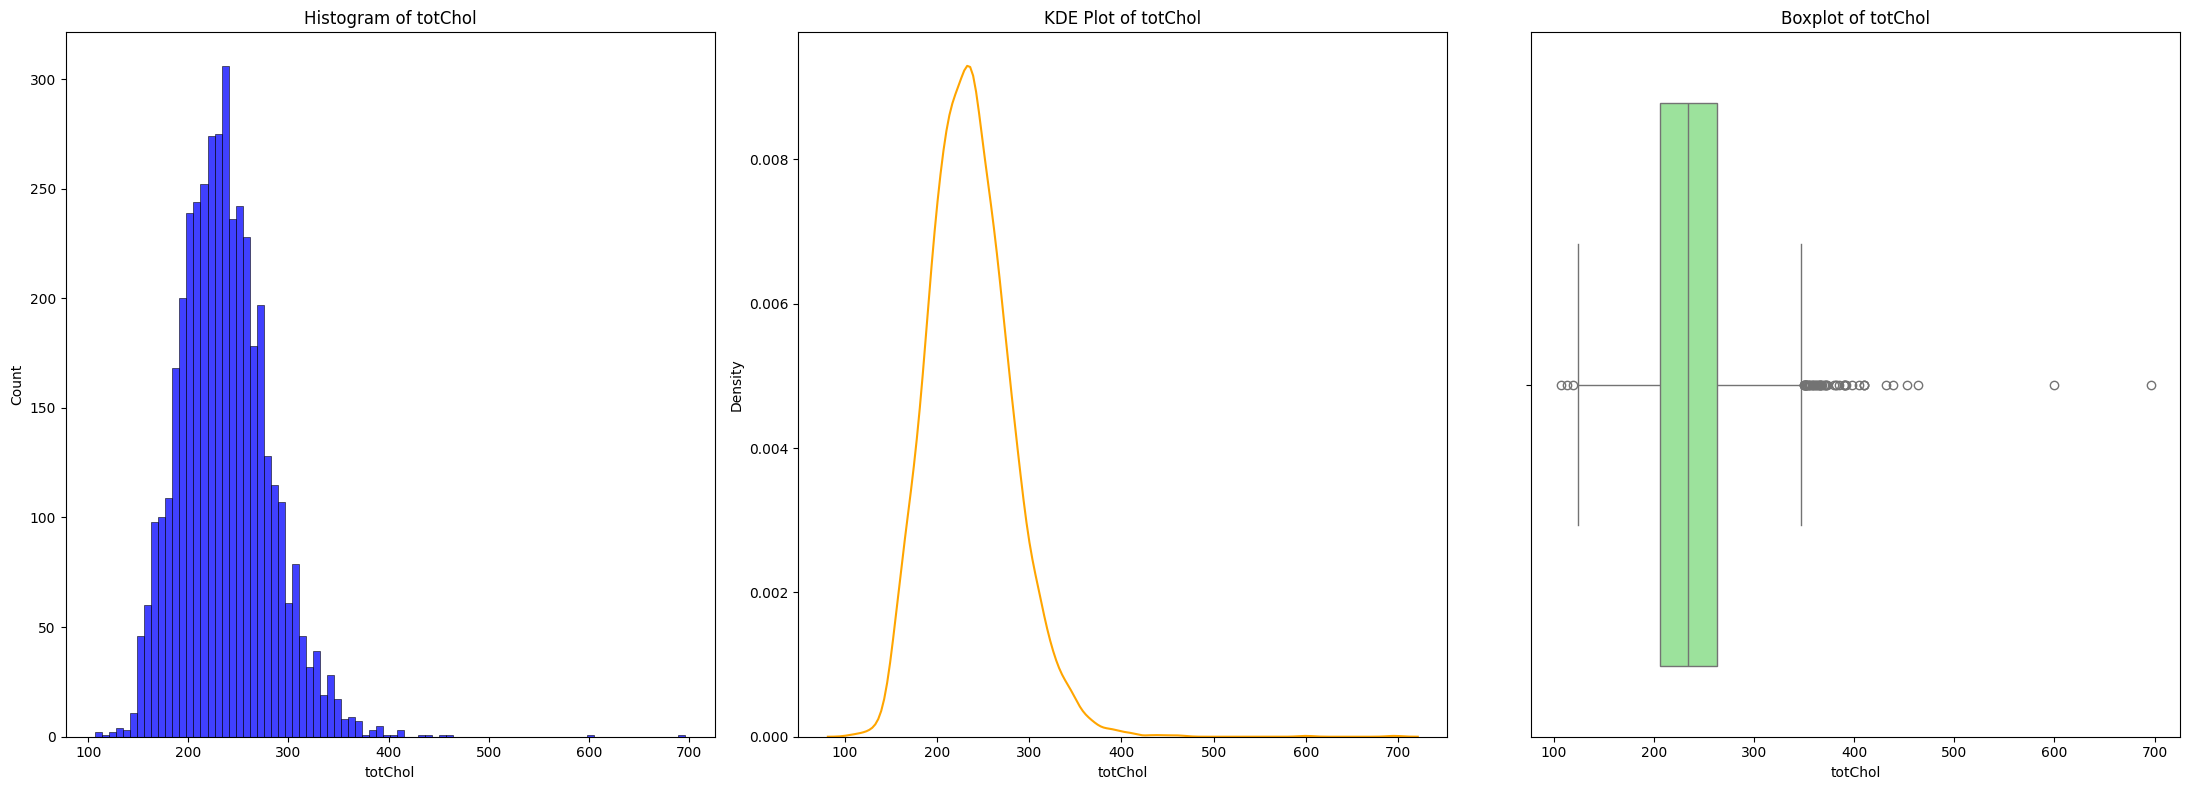

In [21]:
univariate_analysis(eda_df, 'totChol')

# Systolic Blood Pressure

conclusion : 
- Mean : 132.35 and Median : 128.
- Their is No missing value.
- it is right skewed data.
- it contains Outliers as well.

📊 Univariate Analysis for: sysBP

➡️ Summary Statistics:
count    4240.000000
mean      132.354599
std        22.033300
min        83.500000
25%       117.000000
50%       128.000000
75%       144.000000
max       295.000000
Name: sysBP, dtype: float64

🚫 Missing Values: 0

🚫 Missing Values in percentage: 0.000

📈 Skewness: 1.145


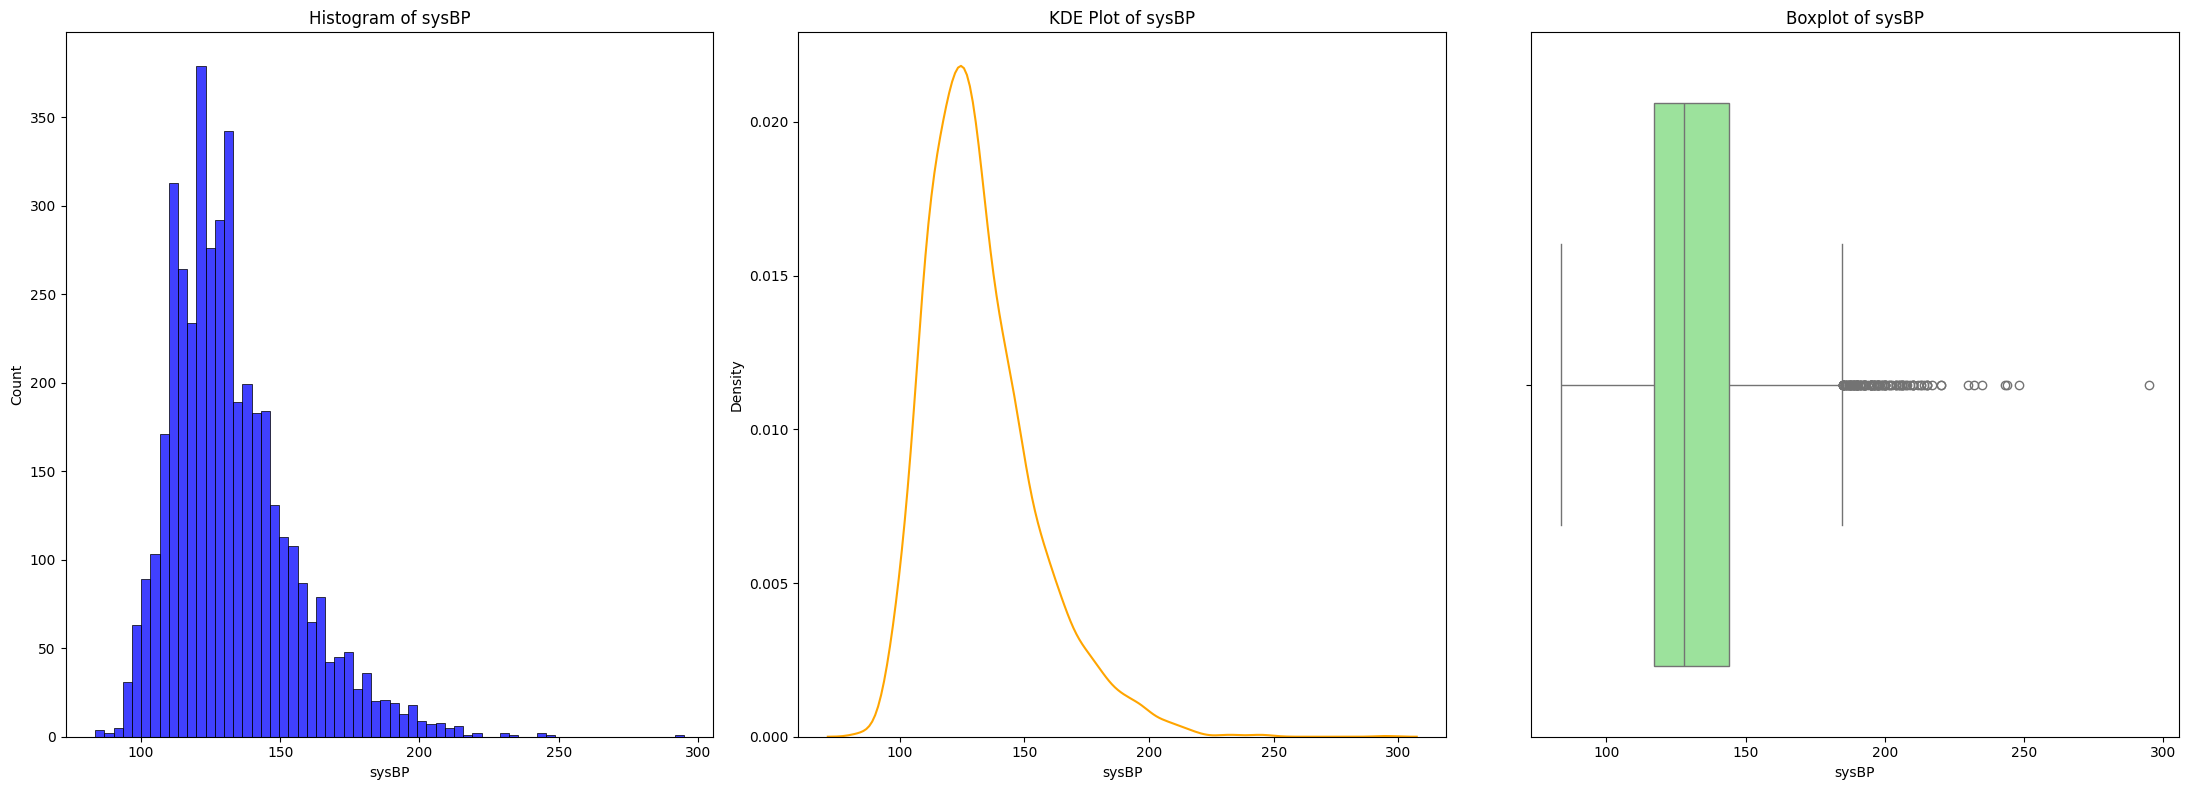

In [22]:
univariate_analysis(eda_df, 'sysBP')

# Diastolic Blood Pressure

conclusion : 
- Mean : 82.89 and Median : 82
- Their is No missing value.
- it is little bit right skewed data.
- it contains Outliers as well.

📊 Univariate Analysis for: diaBP

➡️ Summary Statistics:
count    4240.000000
mean       82.897759
std        11.910394
min        48.000000
25%        75.000000
50%        82.000000
75%        90.000000
max       142.500000
Name: diaBP, dtype: float64

🚫 Missing Values: 0

🚫 Missing Values in percentage: 0.000

📈 Skewness: 0.713


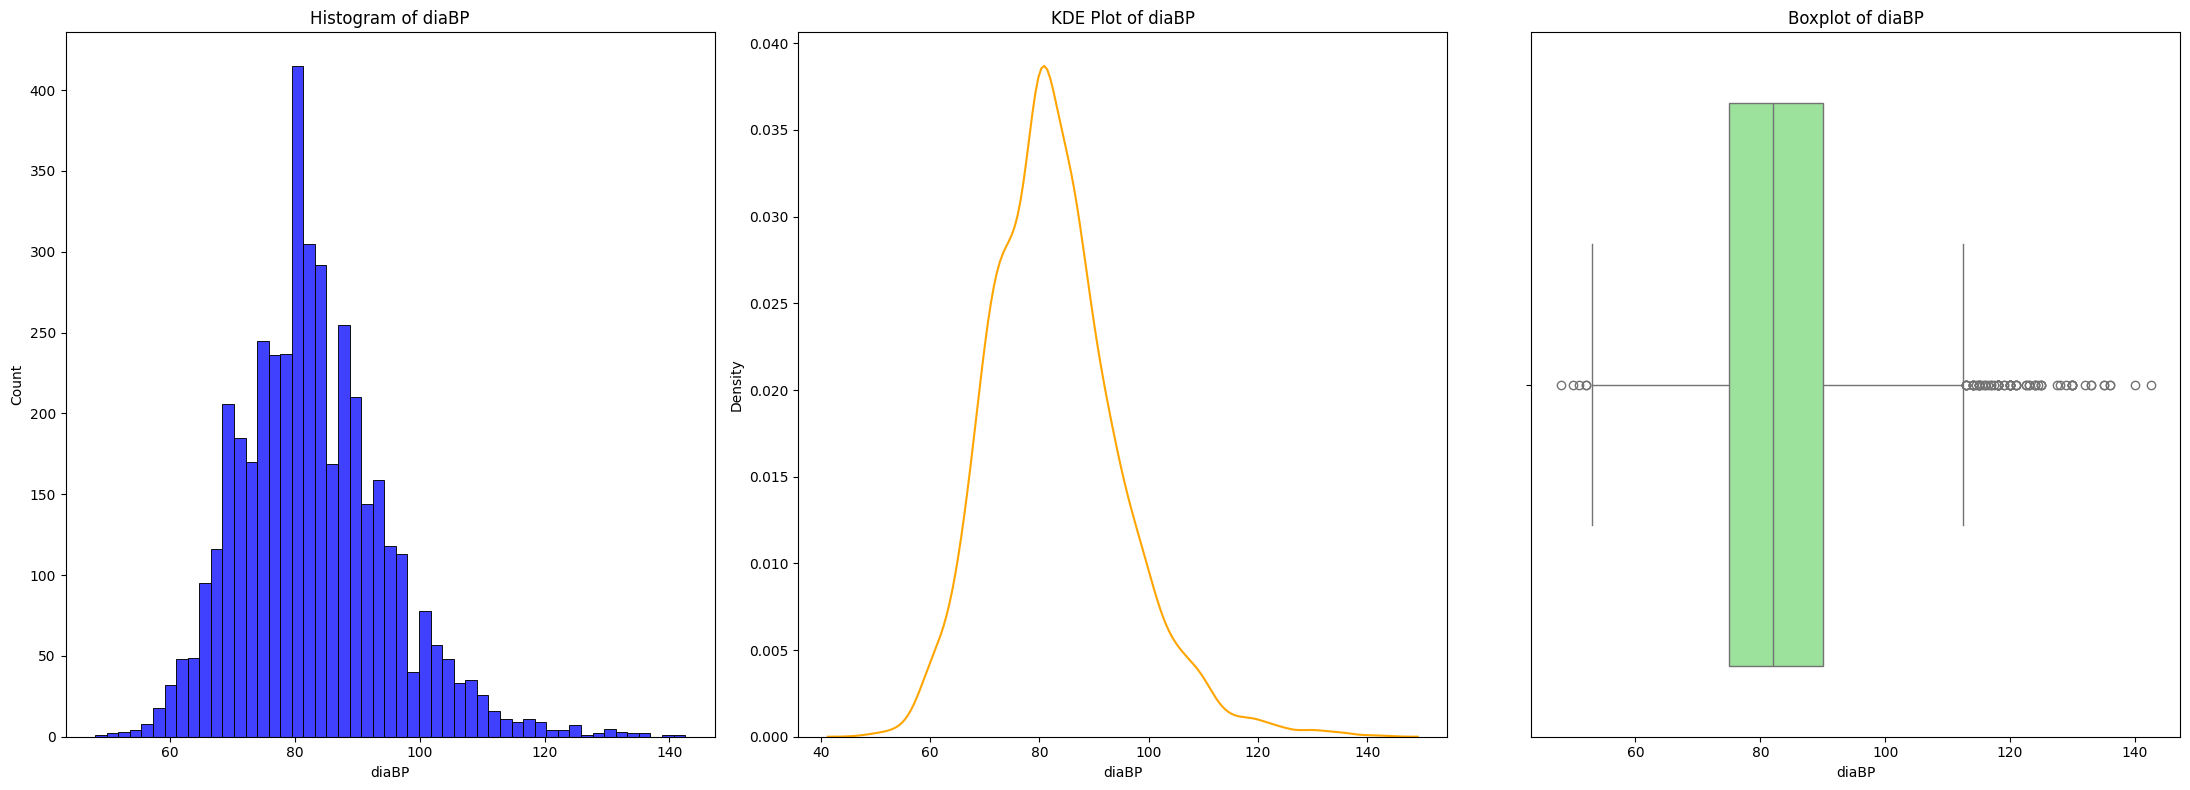

In [23]:
univariate_analysis(eda_df, 'diaBP')

# BMI :- Body Mass Index

conclusion : 
- Mean : 25.8 and Median : 25.4
- Their is 19 missing values and In percentage 0.44
- it is right skewed data.
- it contains Outliers as well.

📊 Univariate Analysis for: BMI

➡️ Summary Statistics:
count    4221.000000
mean       25.800801
std         4.079840
min        15.540000
25%        23.070000
50%        25.400000
75%        28.040000
max        56.800000
Name: BMI, dtype: float64

🚫 Missing Values: 19

🚫 Missing Values in percentage: 0.448

📈 Skewness: 0.982


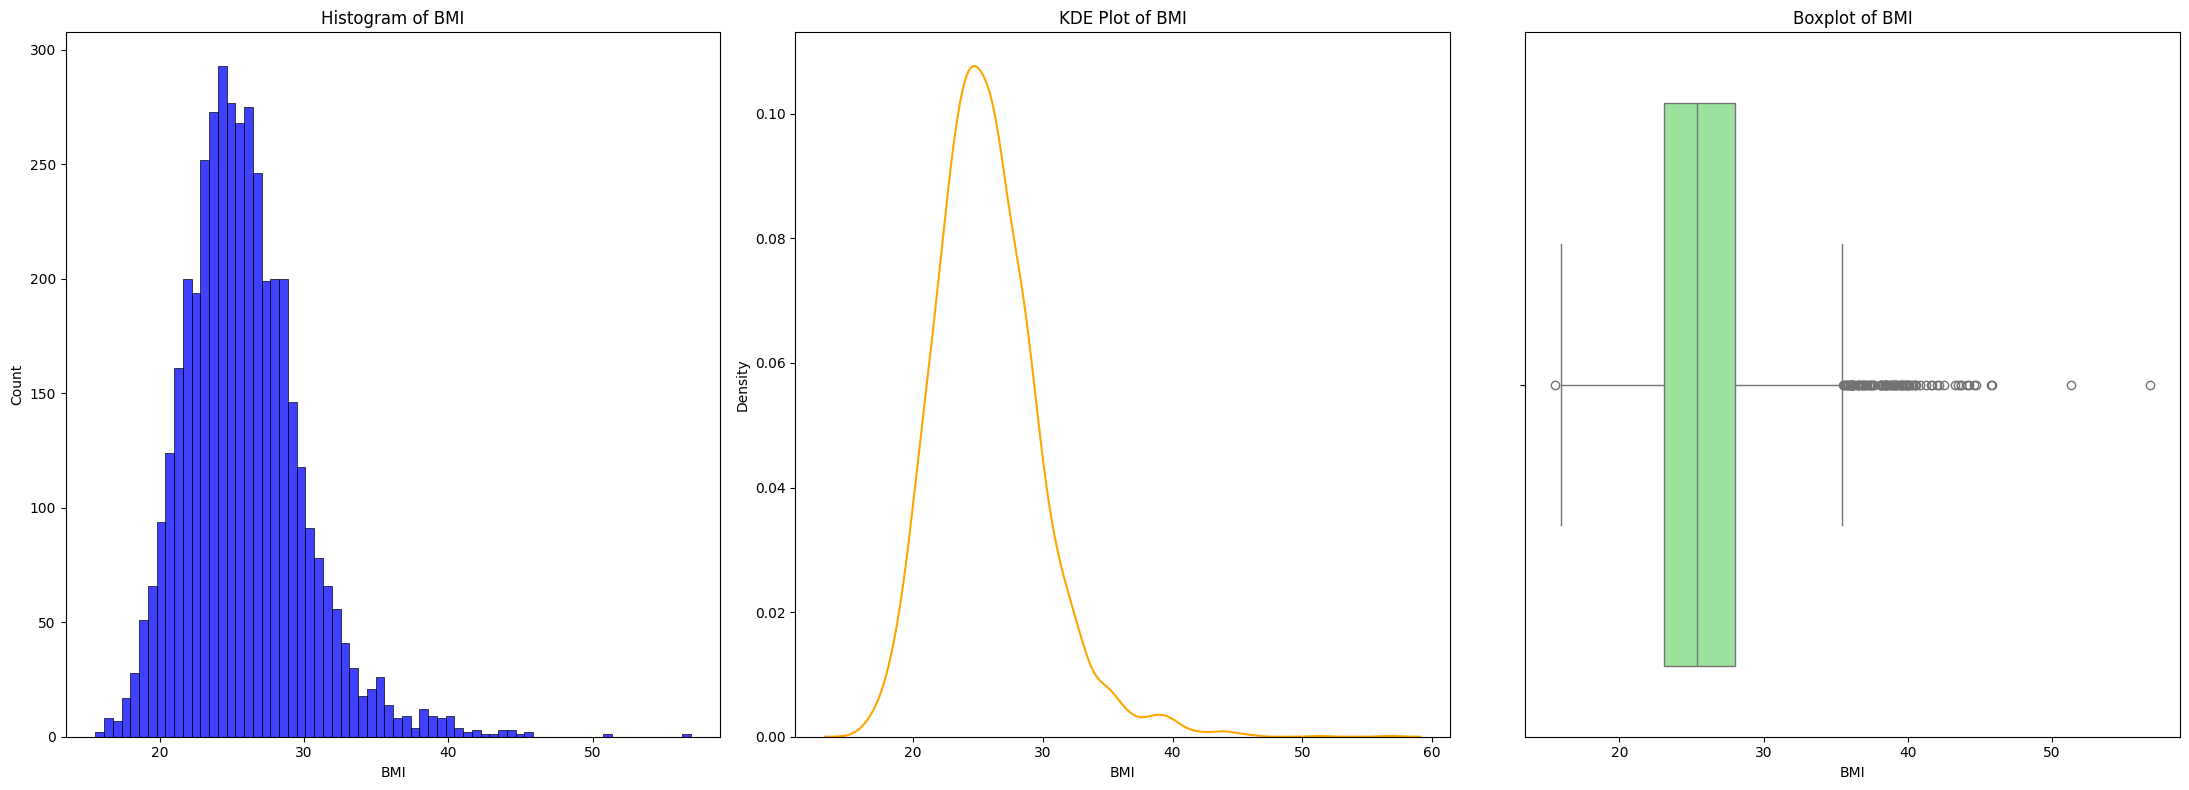

In [24]:
univariate_analysis(eda_df, 'BMI')

# Heart Rate

conclusion : 
- Mean : 75.87 and Median : 75
- Their is 1 missing values and In percentage 0.023
- it is little bit right skewed data.
- it contains Outliers as well.

📊 Univariate Analysis for: heartRate

➡️ Summary Statistics:
count    4239.000000
mean       75.878981
std        12.025348
min        44.000000
25%        68.000000
50%        75.000000
75%        83.000000
max       143.000000
Name: heartRate, dtype: float64

🚫 Missing Values: 1

🚫 Missing Values in percentage: 0.024

📈 Skewness: 0.644


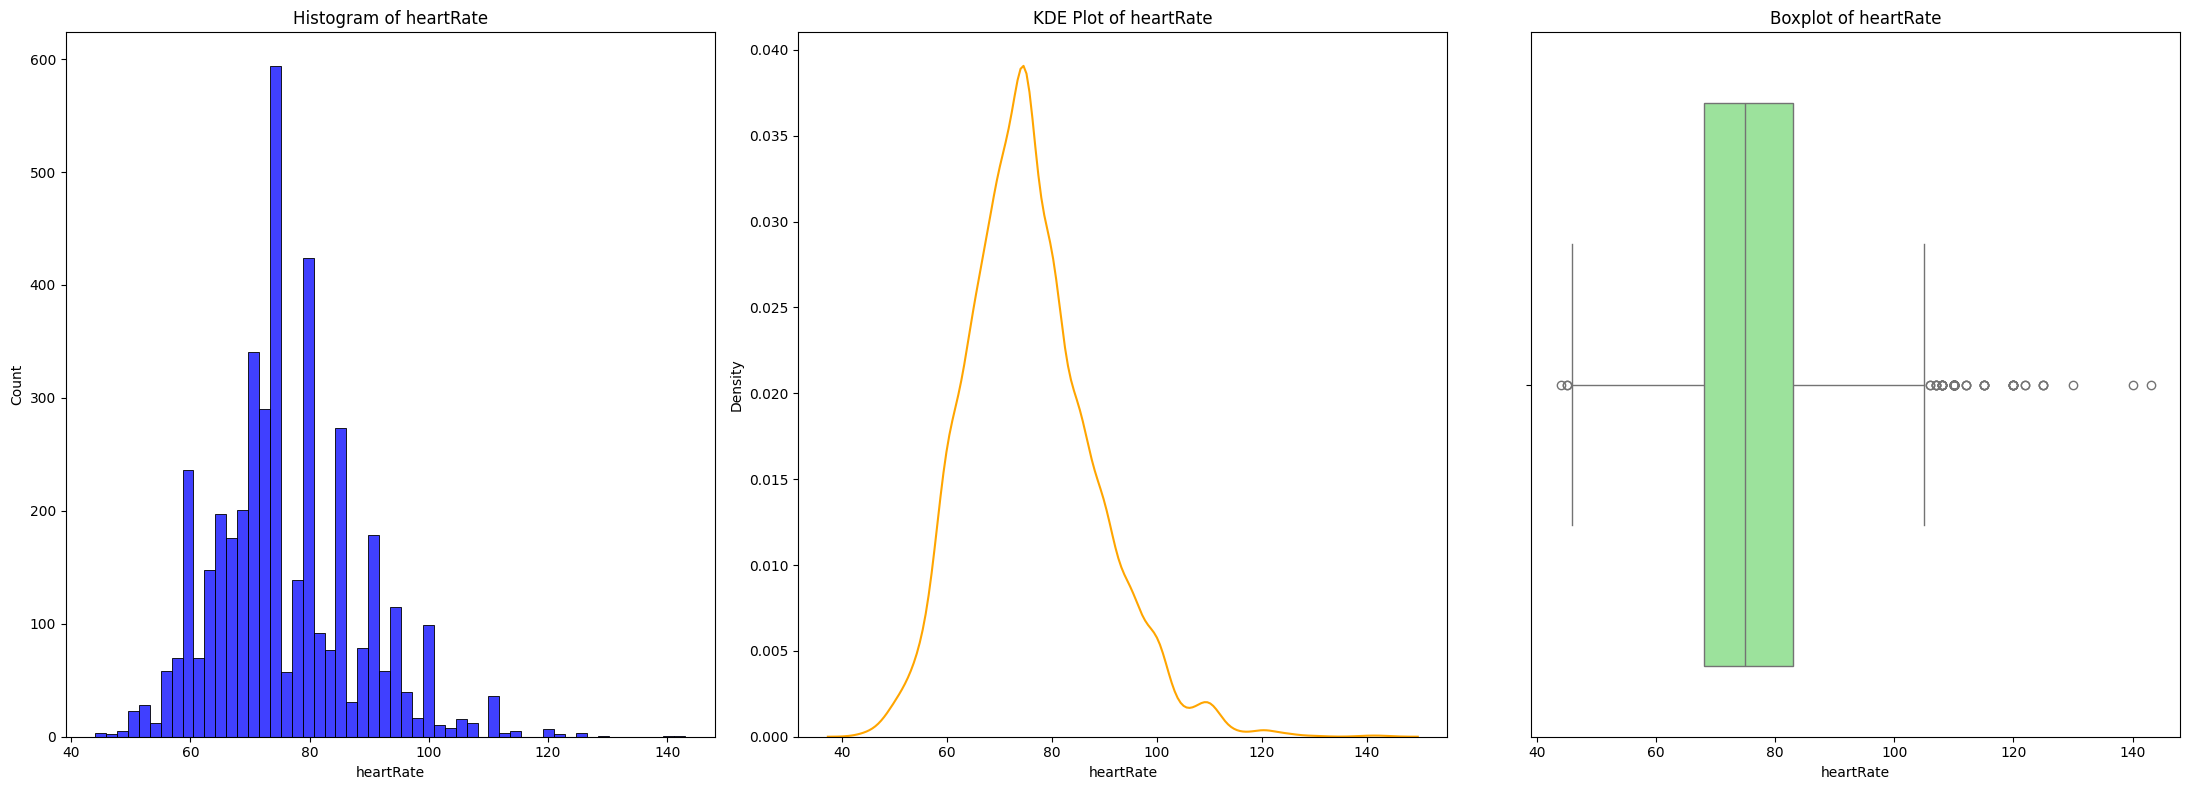

In [25]:
univariate_analysis(eda_df, 'heartRate')

# Glucose

conclusion : 
- Mean : 81.96 and Median : 78
- Their is 388 missing values and In percentage it is 9.15
- it is right skewed data.
- it contains Outliers as well.

📊 Univariate Analysis for: glucose

➡️ Summary Statistics:
count    3852.000000
mean       81.963655
std        23.954335
min        40.000000
25%        71.000000
50%        78.000000
75%        87.000000
max       394.000000
Name: glucose, dtype: float64

🚫 Missing Values: 388

🚫 Missing Values in percentage: 9.151

📈 Skewness: 6.215


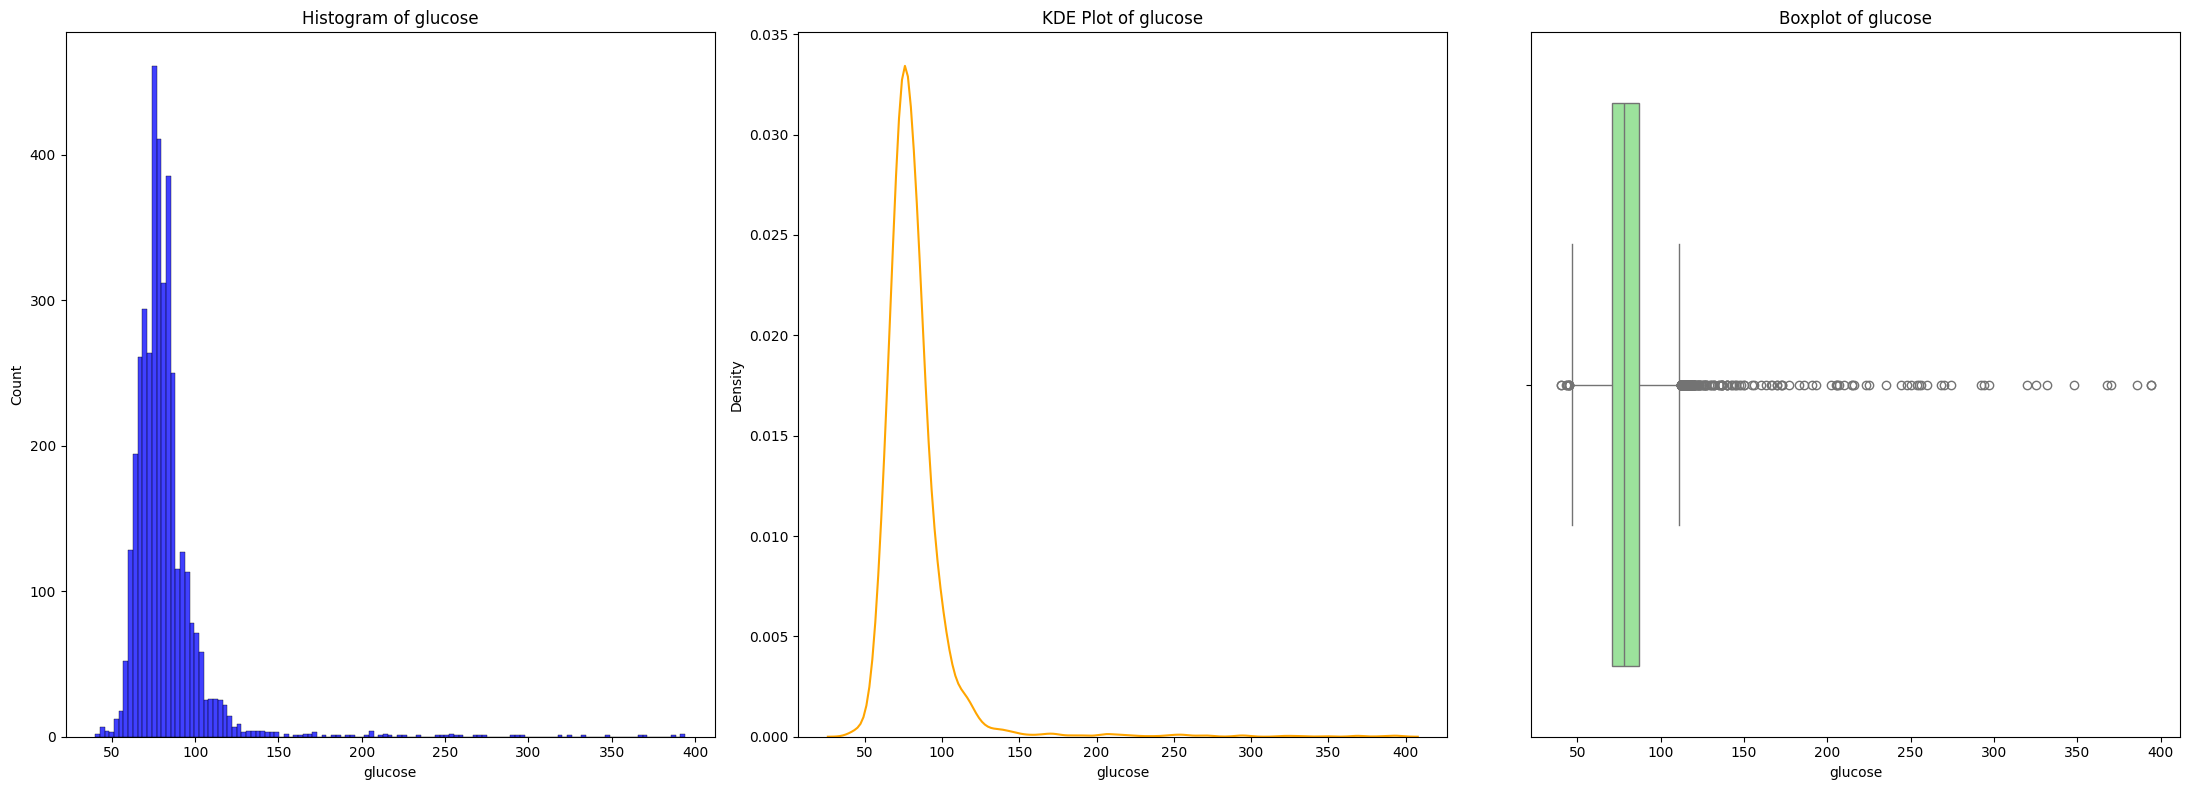

In [26]:
univariate_analysis(eda_df, 'glucose')

In [27]:
eda_df.columns

Index(['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD'],
      dtype='object')

# Lets Start The Univariant Analysis on Categorical Column.

Categorical columns :- Gender, Education, currentSmoker, cigsPerDay, BPMeds, prevalentStroke, prevalentHyp, diabetes, TenYearCHD

# TenYearCHD

conclusion
- Their is no missing value in data
- In Given data, the risk of TenYearCHD is less

In [28]:
eda_df['TenYearCHD'].value_counts()

TenYearCHD
0    3596
1     644
Name: count, dtype: int64

<Axes: xlabel='TenYearCHD'>

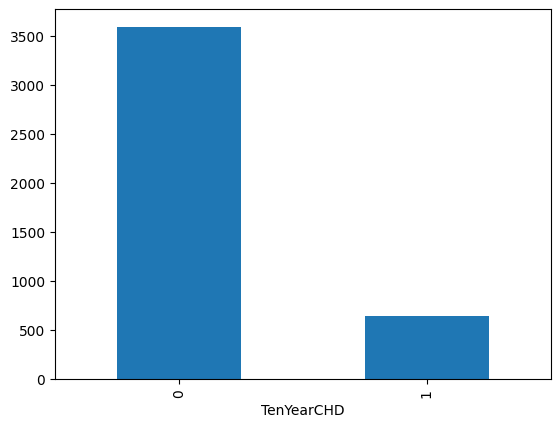

In [29]:
eda_df['TenYearCHD'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

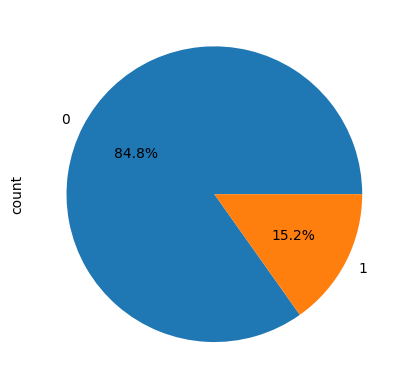

In [30]:
eda_df['TenYearCHD'].value_counts().plot(kind='pie',autopct="%0.1f%%")

In [31]:
eda_df['TenYearCHD'].isnull().sum()

np.int64(0)

# so we do this on all Categorical columns so we make a helper function to perform things

In [32]:
eda_df = eda_df.rename(columns={'male': 'gender'})

In [33]:
eda_df

,gender,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0


In [34]:
def cat_summary(df, column):
    
    print(f"📊 Univariate Analysis of '{column}'")
    print("=" * 60)

    # Info
    print(f"Data Type: {df[column].dtype}\n")

    print("🔹 Value Counts:")
    print(df[column].value_counts())

    print("\n🔹 Value Counts (%)")
    print((df[column].value_counts(normalize=True) * 100).round(2))

    print("\n❌ Missing Values:", df[column].isnull().sum())

    # Colors (Set2 palette)
    colors = sns.color_palette("Set2", df[column].nunique())

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # --- Bar Plot (Seaborn 0.14+ SAFE version) ---
    sns.countplot(
        data=df,
        x=column,
        hue=column,            # ← required for palette
        palette=colors,
        legend=False,          # ← hide legend
        ax=axes[0]
    )
    axes[0].set_title(f"Bar Plot of {column}")
    axes[0].tick_params(axis="x", rotation=45)

    # --- Pie Chart ---
    df[column].value_counts().plot(
        kind="pie",
        autopct="%0.1f%%",
        colors=colors,
        ax=axes[1],
        startangle=90,
        wedgeprops={"edgecolor": "black"}
    )
    axes[1].set_ylabel("")
    axes[1].set_title(f"Pie Chart of {column}")

    plt.tight_layout()
    plt.show()


# Gender

conclusions :
- male is in high number as compare to femaale
- male 57.08% and Female 42.92%
- No missing value in my data

📊 Univariate Analysis of 'gender'
Data Type: int64

🔹 Value Counts:
gender
0    2420
1    1820
Name: count, dtype: int64

🔹 Value Counts (%)
gender
0    57.08
1    42.92
Name: proportion, dtype: float64

❌ Missing Values: 0


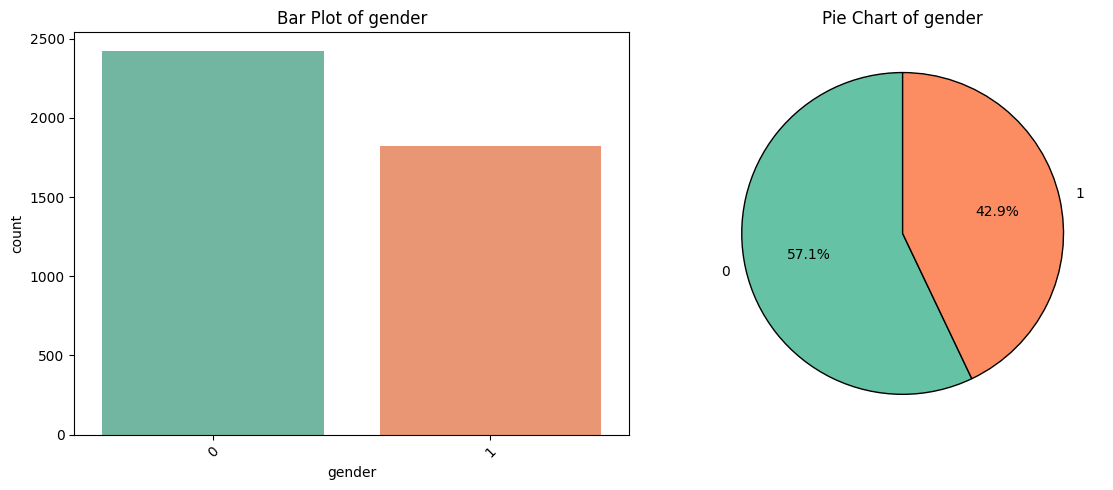

In [35]:
cat_summary(eda_df, 'gender')

# education

conclusions : 
- many person studied less than High School.
- a very little amount of person studied in college around 473(11.44%).
- 105 missing value in my data.

📊 Univariate Analysis of 'education'
Data Type: float64

🔹 Value Counts:
education
1.0    1720
2.0    1253
3.0     689
4.0     473
Name: count, dtype: int64

🔹 Value Counts (%)
education
1.0    41.60
2.0    30.30
3.0    16.66
4.0    11.44
Name: proportion, dtype: float64

❌ Missing Values: 105


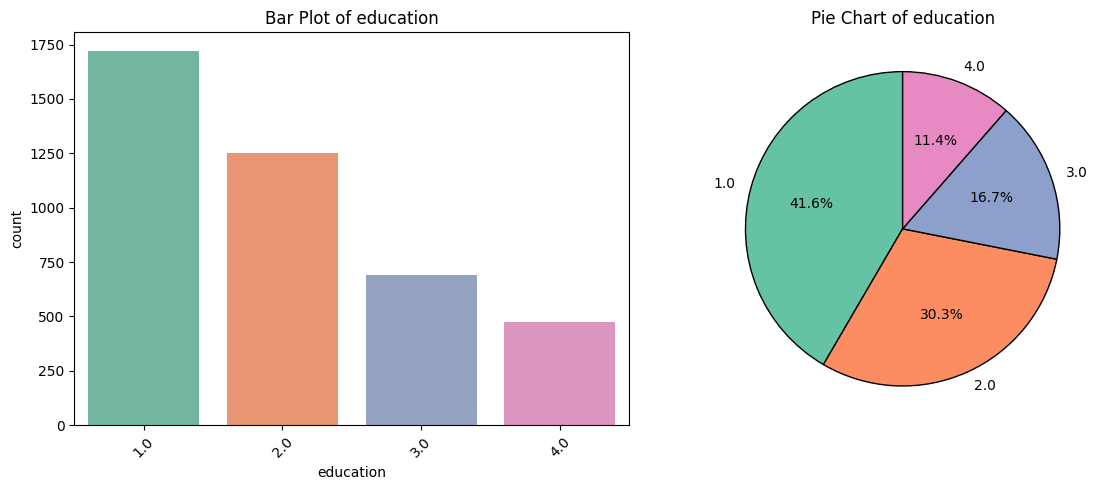

In [36]:
cat_summary(eda_df, 'education')

# CurrentSmoker

conclusions : 
- Their is equal balance between smoker and non-smoker.
- smoker : 2145(50.59%) and non-smoker : 2095(49.41%)
- No missing value in my data.

📊 Univariate Analysis of 'currentSmoker'
Data Type: int64

🔹 Value Counts:
currentSmoker
0    2145
1    2095
Name: count, dtype: int64

🔹 Value Counts (%)
currentSmoker
0    50.59
1    49.41
Name: proportion, dtype: float64

❌ Missing Values: 0


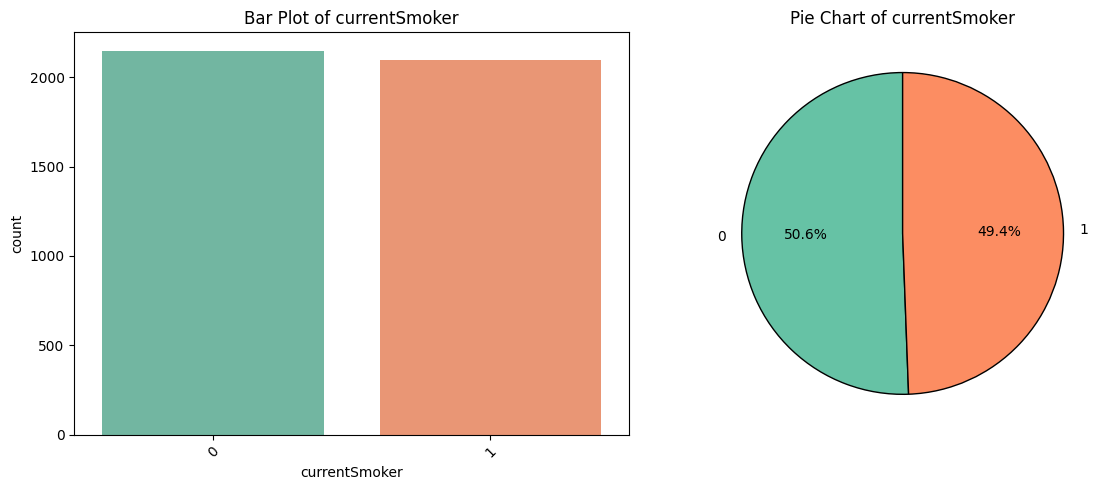

In [37]:
cat_summary(eda_df, 'currentSmoker')

# BPMeds

conclusions : 
- Most Person not take any BP Medication
- a very little amount of person take BP Medication.
- 53 missing value in my data.

📊 Univariate Analysis of 'BPMeds'
Data Type: float64

🔹 Value Counts:
BPMeds
0.0    4063
1.0     124
Name: count, dtype: int64

🔹 Value Counts (%)
BPMeds
0.0    97.04
1.0     2.96
Name: proportion, dtype: float64

❌ Missing Values: 53


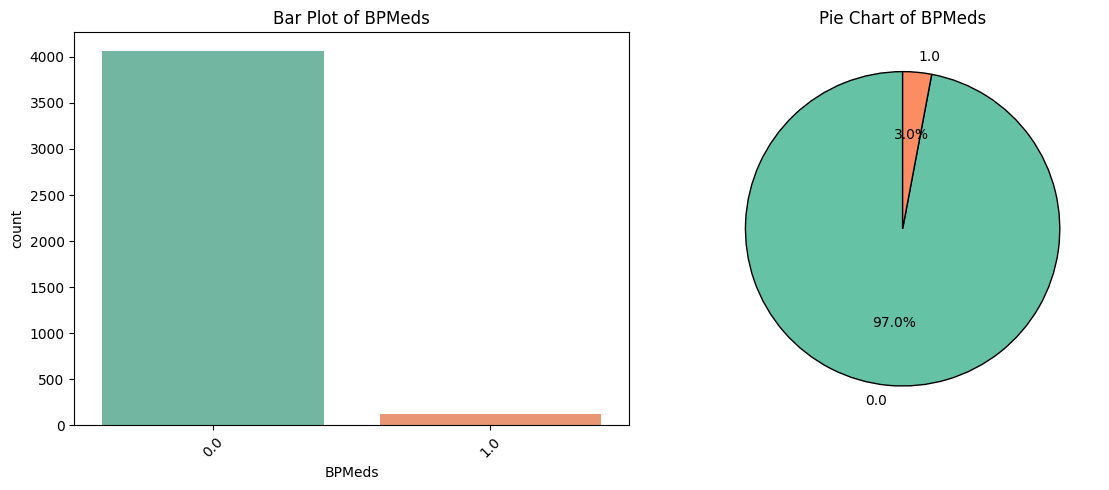

In [38]:
cat_summary(eda_df, 'BPMeds')

# prevalentStroke

conclusions : 
- many person doesn't suffer heart stroke in past
- a very little person suffderd from past stroke to be precised 25(0.59%).
- No missing value in my data.

📊 Univariate Analysis of 'prevalentStroke'
Data Type: int64

🔹 Value Counts:
prevalentStroke
0    4215
1      25
Name: count, dtype: int64

🔹 Value Counts (%)
prevalentStroke
0    99.41
1     0.59
Name: proportion, dtype: float64

❌ Missing Values: 0


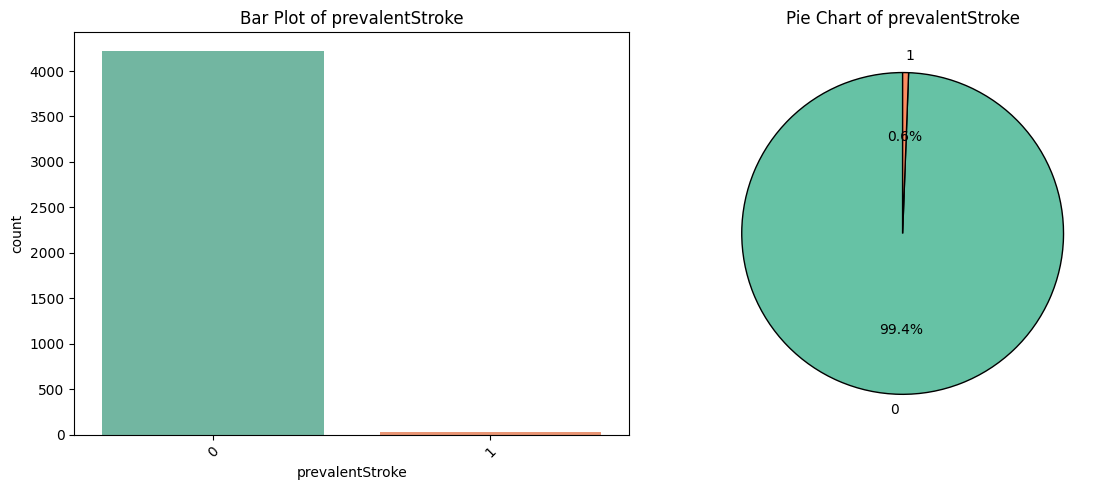

In [39]:
cat_summary(eda_df, 'prevalentStroke')

# prevalentHyp

conclusions : 
- many person have suffered High Blood person.
- High BP : 2923(68.94%) & Low BP : 1317(31.06%)
- 105 missing value in my data.

📊 Univariate Analysis of 'prevalentHyp'
Data Type: int64

🔹 Value Counts:
prevalentHyp
0    2923
1    1317
Name: count, dtype: int64

🔹 Value Counts (%)
prevalentHyp
0    68.94
1    31.06
Name: proportion, dtype: float64

❌ Missing Values: 0


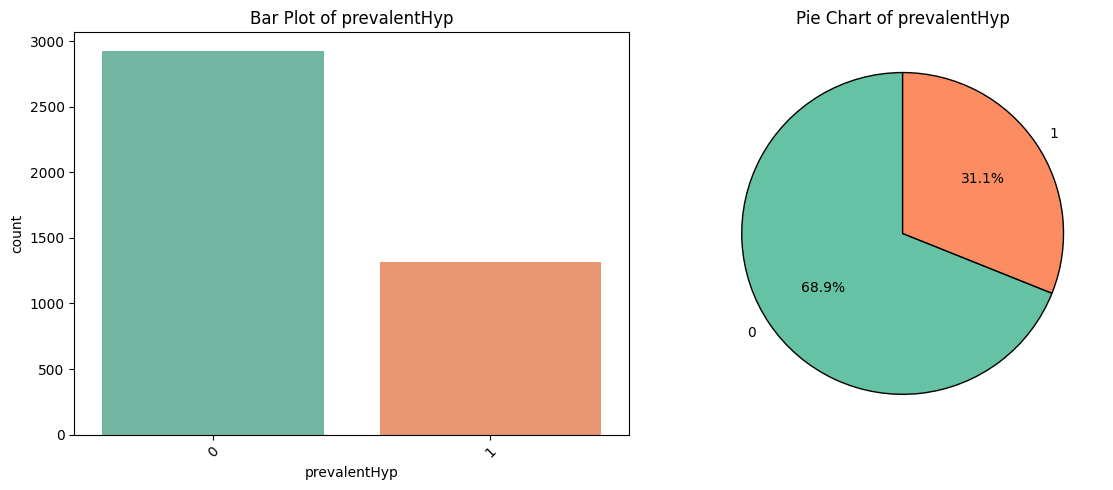

In [40]:
cat_summary(eda_df, 'prevalentHyp')

# Diabetes

conclusions : 
- Most Person don't have Diabetes.
- no diabetes : 4131(97.43%) & diabetes : 109(2.57%)
- NO missing value in my data.

📊 Univariate Analysis of 'diabetes'
Data Type: int64

🔹 Value Counts:
diabetes
0    4131
1     109
Name: count, dtype: int64

🔹 Value Counts (%)
diabetes
0    97.43
1     2.57
Name: proportion, dtype: float64

❌ Missing Values: 0


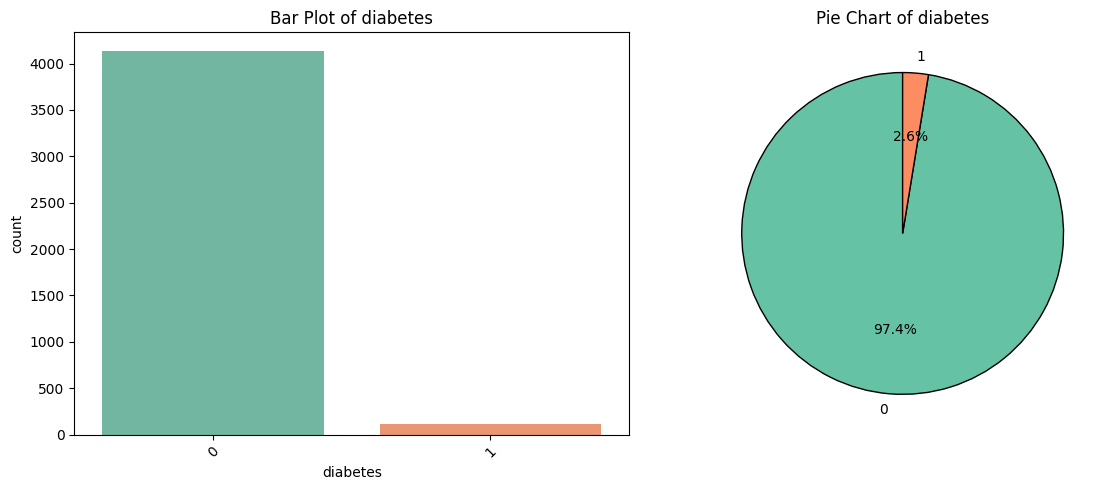

In [41]:
cat_summary(eda_df, 'diabetes')

# TenYearCHD

conclusions : 
- In future, Most person will avoid this Chronic Heart Diasease.
- No CHD : 3596(84.81%) & CHD : 644(15.19%)

📊 Univariate Analysis of 'TenYearCHD'
Data Type: int64

🔹 Value Counts:
TenYearCHD
0    3596
1     644
Name: count, dtype: int64

🔹 Value Counts (%)
TenYearCHD
0    84.81
1    15.19
Name: proportion, dtype: float64

❌ Missing Values: 0


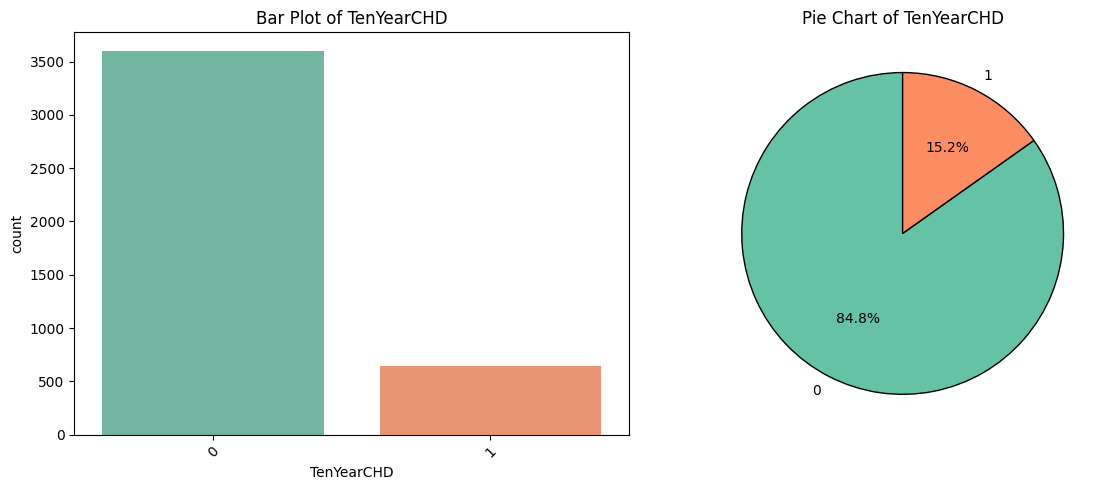

In [42]:
cat_summary(eda_df, 'TenYearCHD')

# Now We Moved Towards The BIvariant Analysis

- First we Take Categorical - catergorical column.

In [43]:
eda_df

,gender,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0


# Conclusion TenYearCHD and gender

- Females have lower overall cases of TenYearCHD compared to males.

- When looking only at the people who DO have TenYearCHD:

- the number of males (343) and females (301) is fairly balanced, meaning heart disease affects both genders significantly.


In [44]:
pd.crosstab(eda_df['TenYearCHD'],eda_df['gender'])

gender,0,1
TenYearCHD,,
0,2119,1477
1,301,343


<Axes: xlabel='gender', ylabel='TenYearCHD'>

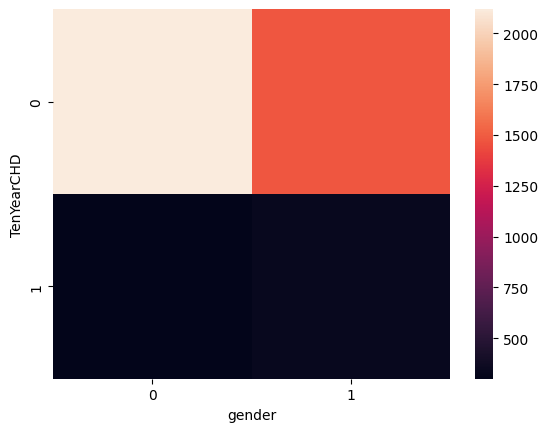

In [45]:
sns.heatmap(pd.crosstab(eda_df['TenYearCHD'],eda_df['gender']))

<Axes: xlabel='gender', ylabel='TenYearCHD'>

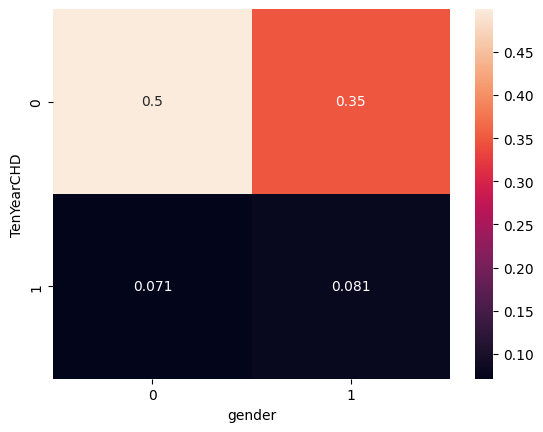

In [46]:
sns.heatmap(pd.crosstab(eda_df['TenYearCHD'],eda_df['gender'],normalize=True), annot=True)

# Helper Function for doing this thing perfectly.

In [47]:
def cat_bivariate(df, col1, col2, normalize=False):
    """
    Perform bivariate analysis between two categorical columns.
    Shows crosstab and heatmap.

    Parameters:
    df : DataFrame
    col1 : str -> First categorical column (e.g., target column)
    col2 : str -> Second categorical column (e.g., feature)
    normalize : bool -> If True, show proportions (%) instead of raw counts
    """

    print(f"🔍 Bivariate Analysis between '{col1}' and '{col2}'")
    print("=" * 70)

    # Create cross-tab
    if normalize:
        ct = pd.crosstab(df[col1], df[col2], normalize='index') * 100
    else:
        ct = pd.crosstab(df[col1], df[col2])
    
    # Display table
    print("\n📊 Crosstab Table:")
    print(ct.round(2))

    # Plot heatmap
    plt.figure(figsize=(10, 5))
    sns.heatmap(ct, annot=True, cmap="YlGnBu", fmt=".1f" if normalize else "d")
    plt.title(f"Heatmap of {col1} vs {col2}")
    plt.xlabel(col2)
    plt.ylabel(col1)
    plt.show()

# Conclusion TenYearCHD and currentsmoker

- Person who smoke have hihger percentage of risk having Chronic heart Disease(51.71%) then the non-smoker.


🔍 Bivariate Analysis between 'TenYearCHD' and 'currentSmoker'

📊 Crosstab Table:
currentSmoker      0      1
TenYearCHD                 
0              51.00  49.00
1              48.29  51.71


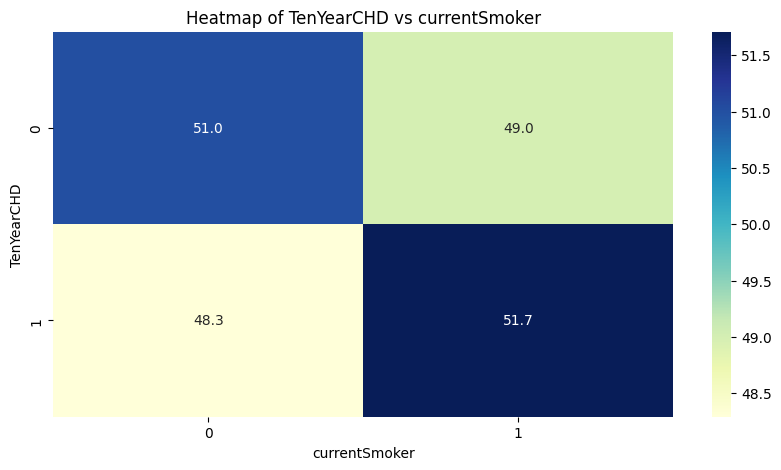

In [48]:
cat_bivariate(eda_df, 'TenYearCHD', 'currentSmoker', normalize=True)

# Conclusion on TenYearCHD or BPmeds

- People who take blood pressure medication (BPMeds = 1) have a higher percentage of TenYearCHD compared to those who do not take medication.

# Insight Breakdown

- Among individuals without CHD (TenYearCHD = 0):
    Only 2.34% are taking BP medication.

- Among individuals with CHD (TenYearCHD = 1):
    6.48% are taking BP medication.

This means the proportion of people on BP medication is almost 3× higher in the CHD group.

🔍 Bivariate Analysis between 'TenYearCHD' and 'BPMeds'

📊 Crosstab Table:
BPMeds        0.0   1.0
TenYearCHD             
0           97.66  2.34
1           93.52  6.48


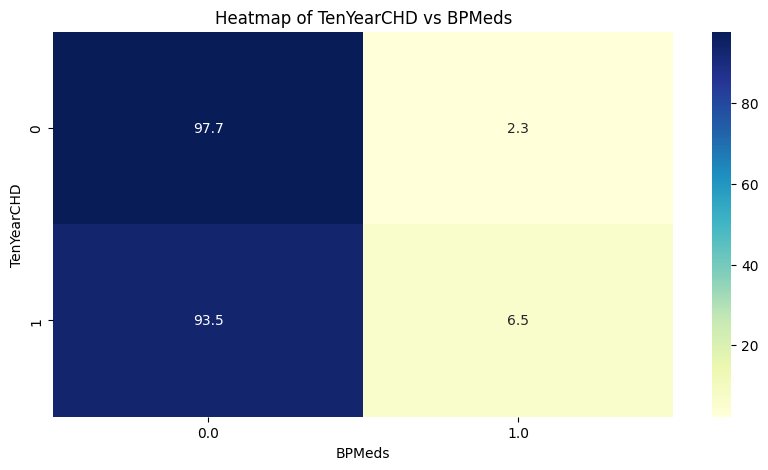

In [49]:
cat_bivariate(eda_df, 'TenYearCHD', 'BPMeds', normalize=True)

# Conclusion on TenYearCHD or prevalentStroke

- People who have experienced a previous stroke (prevalentStroke = 1) show a higher likelihood of developing TenYearCHD compared to those with no stroke history.

# Insight Breakdown

- Among individuals without CHD (TenYearCHD = 0):
Only 0.39% have a history of stroke.

- Among individuals with CHD (TenYearCHD = 1):
1.71% have a history of stroke.

This means the proportion of stroke cases is over 4× higher in the CHD group.

🔍 Bivariate Analysis between 'TenYearCHD' and 'prevalentStroke'

📊 Crosstab Table:
prevalentStroke      0     1
TenYearCHD                  
0                99.61  0.39
1                98.29  1.71


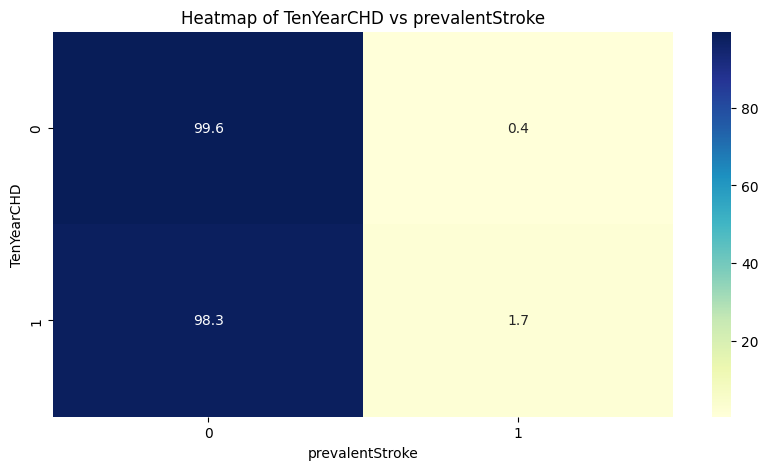

In [50]:
cat_bivariate(eda_df, 'TenYearCHD', 'prevalentStroke', normalize=True)

# Conclusion on TenYearCHD or diabetes

- People who have diabetes have a strong contender of CHD.

# Insight Breakdown

- Among individuals without CHD (TenYearCHD = 0):
Only 1.92% have a history of diabetes.

- Among individuals with CHD (TenYearCHD = 1):
6.21% have a history of diabetes.

This means the proportion of stroke cases is over 3× higher in the CHD group.

🔍 Bivariate Analysis between 'TenYearCHD' and 'diabetes'

📊 Crosstab Table:
diabetes        0     1
TenYearCHD             
0           98.08  1.92
1           93.79  6.21


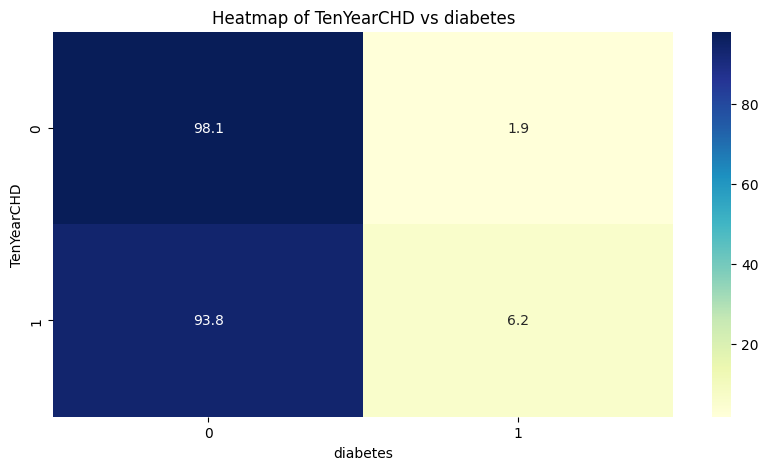

In [51]:
cat_bivariate(eda_df, 'TenYearCHD', 'diabetes', normalize=True)

# Now let's move towards the Bivarinat Analysis Numerical and Categorical column.

In [52]:
eda_df

,gender,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0


In [53]:
def num_bivariate_plot(df, num_col, target_col='TenYearCHD'):
    """
    Creates boxplot and barplot for a numerical column against a target categorical column.
    
    Parameters:
    df       : DataFrame
    num_col  : Numerical column name (string)
    target_col : Categorical target column name (default='TenYearCHD')
    """
    
    print(f"📊 Bivariate Analysis between '{target_col}' and '{num_col}'")
    print("=" * 70)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # -------- Boxplot --------
    sns.boxplot(
        data=df,
        x=target_col,
        y=num_col,
        hue=target_col,
        ax=axes[0],
        palette="Set2"
    )
    axes[0].set_title(f"Boxplot: {num_col} vs {target_col}")
    axes[0].set_xlabel(target_col)
    axes[0].set_ylabel(num_col)

    # -------- Barplot (Mean Comparison) --------
    sns.barplot(
        data=df,
        x=target_col,
        y=num_col,
        hue=target_col,
        ax=axes[1],
        palette="Set2",
        estimator='mean'
    )
    axes[1].set_title(f"Mean {num_col} by {target_col}")
    axes[1].set_xlabel(target_col)
    axes[1].set_ylabel(f"Mean {num_col}")

    plt.tight_layout()
    plt.show()

# conclusion on TenYearCHD and Age

- Based on the bivariate analysis between Age and TenYearCHD, the following insights are observed:

- Individuals without CHD (TenYearCHD = 0) have a median age of ~48 years.

- Individuals with CHD (TenYearCHD = 1) have a higher median age of ~55 years.

The mean age for the non-CHD group is approximately 49.5 years,
while the mean age for the CHD group increases to around 53 years.

✔️ Interpretation

Age appears to be a significant factor influencing CHD risk.
People who eventually develop CHD tend to be older on average compared to those who don’t.
This trend is clearly visible from both the boxplot (distribution + medians) and the barplot (mean comparison).

📊 Bivariate Analysis between 'TenYearCHD' and 'age'


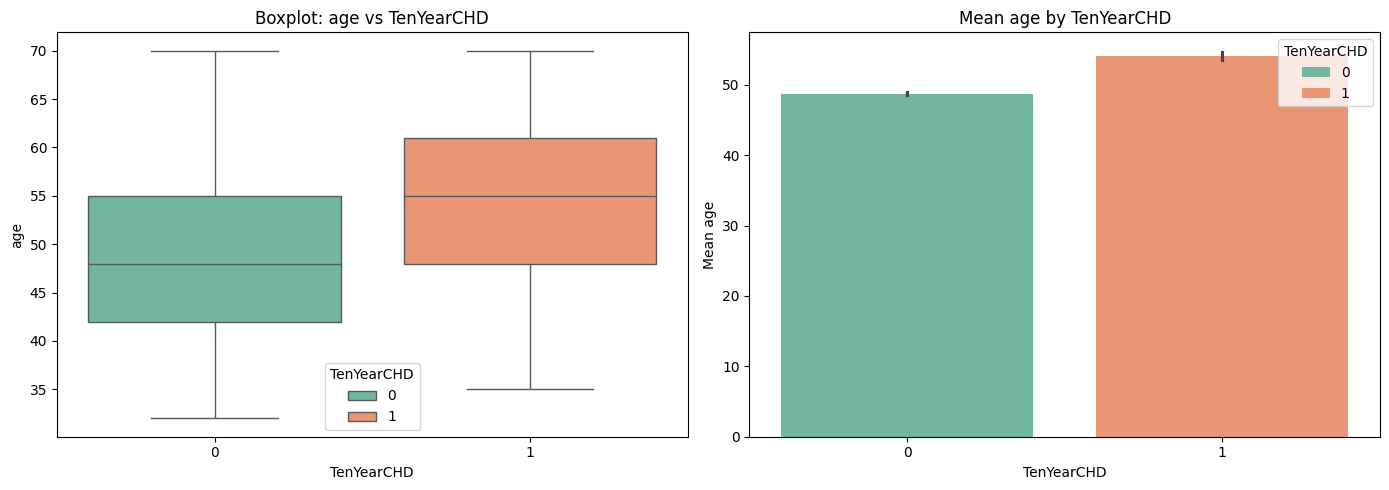

In [54]:
num_bivariate_plot(eda_df, 'age')

# conclusion on TenYearCHD and totChol

- Based on the bivariate analysis between totChol and TenYearCHD, the following insights are observed:

- Individuals without CHD (TenYearCHD = 0) have a median totChol of ~220.

- Individuals with CHD (TenYearCHD = 1) have a higher median totChol of ~225.

- The mean totChol for the non-CHD group is approximately 235.

- The mean totChol for the CHD group increases to around 245.

✔️ Interpretation

totChol appears to be a significant factor influencing CHD risk.

People who eventually develop CHD tend to be Higher on average compared to those who don’t.

This trend is clearly visible from both the boxplot (distribution + medians) and the barplot (mean comparison).

📊 Bivariate Analysis between 'TenYearCHD' and 'totChol'


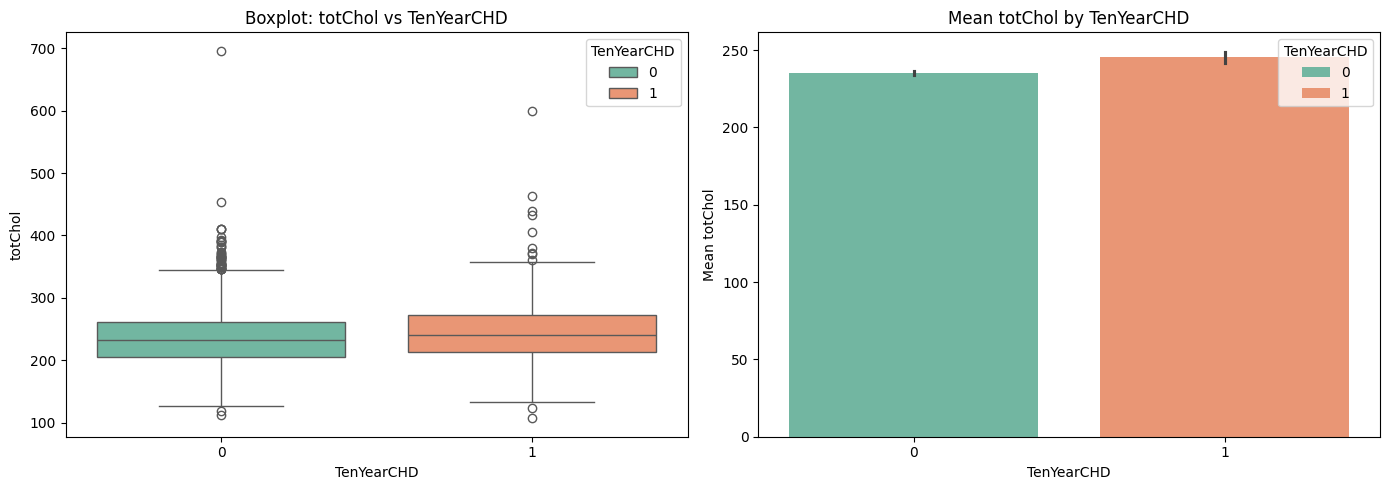

In [55]:
num_bivariate_plot(eda_df, 'totChol')

# conclusion on TenYearCHD and BMI

📌 Key Statistical Insights

- Individuals without CHD (TenYearCHD = 0) have a median BMI around 25.

- Individuals with CHD (TenYearCHD = 1) have a slightly higher median BMI around 26.

- The mean BMI for:

- Non-CHD group: ~25.2

CHD group: ~26.5 to 27 (slightly higher)

✔️ Interpretation

- People who develop CHD tend to have higher BMI levels, though the difference is moderate, not very large.

- The boxplot shows that the CHD group has a slightly upward-shifted BMI distribution, with more higher-BMI individuals.

- This suggests that BMI may have a noticeable (but not extreme) association with CHD risk.

📘 Final Takeaway

👉 Higher BMI is modestly associated with increased Ten-Year CHD risk in this dataset.
While not the strongest predictor, BMI still shows a consistent upward trend among people who eventually develop CHD.

📊 Bivariate Analysis between 'TenYearCHD' and 'BMI'


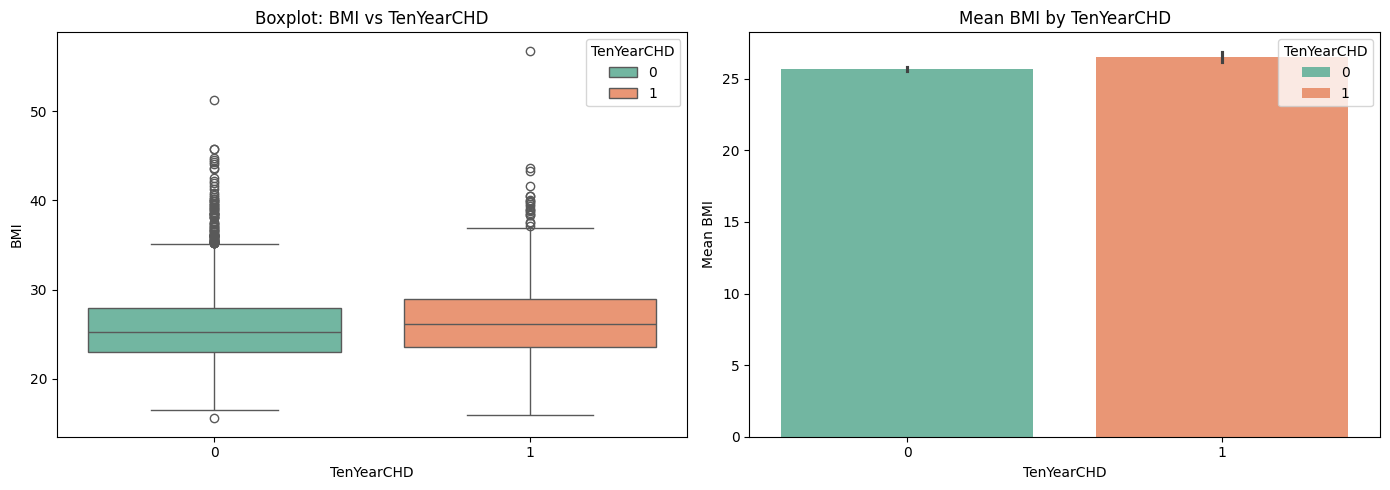

In [56]:
num_bivariate_plot(eda_df, 'BMI')

# Conclusions on tenYearCHD and HeartRate

📌 Key Statistical Insights

- Individuals without CHD (TenYearCHD = 0) have a median heart rate of ~76.

- Individuals with CHD (TenYearCHD = 1) have a slightly lower median heart rate of ~75.

- The mean heart rate for the non-CHD group is ~75.

- The mean heart rate for the CHD group is ~76.

✔️ Interpretation

- The heart rate differences between CHD and non-CHD groups are very small and not clinically significant.

- There is no strong pattern showing that higher or lower heart rate is directly associated with CHD development.

Although the CHD group shows a slightly higher mean heart rate, the overlap in distributions is large, and the medians differ by only ~1 bpm, which is negligible.

📘 Final takeaway

👉 Heart rate does not appear to be a strong predictor of Ten-Year CHD risk based on this dataset.

📊 Bivariate Analysis between 'TenYearCHD' and 'heartRate'


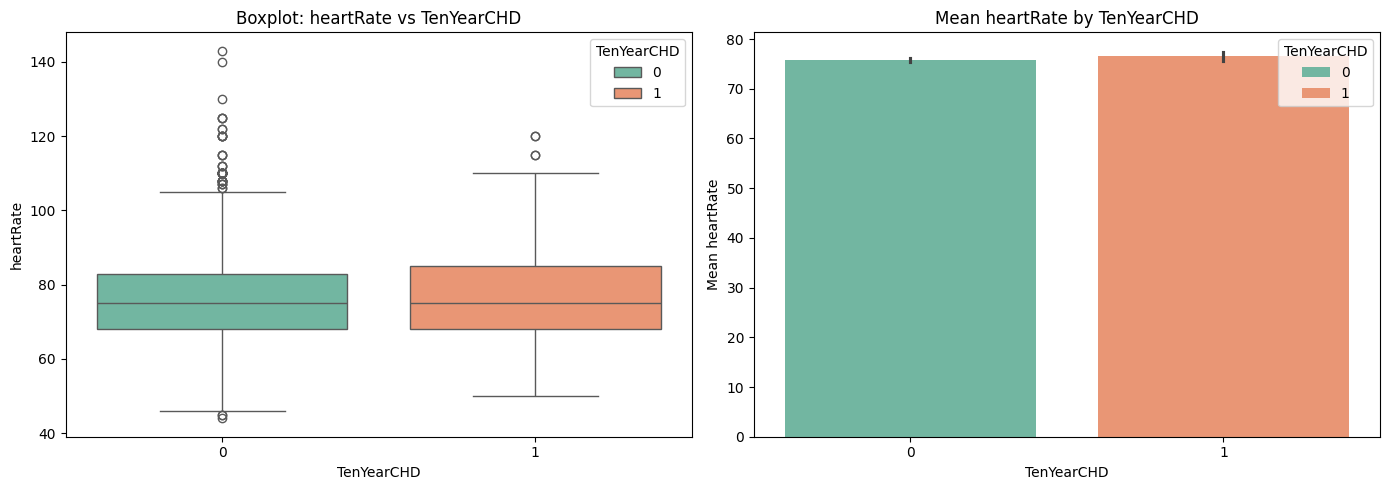

In [57]:
num_bivariate_plot(eda_df, 'heartRate')

# Now we Make Age Column into categorical and getting some more insights

In [58]:
eda_df

,gender,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0


In [59]:
def convert_age(num):
    if num <= 30:
        return "Low"
    elif num <= 60:   # because >30 is already handled
        return "Medium"
    else:
        return "High"

In [60]:
eda_df["AgeCategory"] = eda_df["age"].apply(convert_age)

In [61]:
eda_df

,gender,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD,AgeCategory
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0,Medium
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0,Medium
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0,Medium
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1,High
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0,Medium
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0,Medium
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0,Medium
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0,Medium


# Conclusion on TenYearCHD and Age Category

Among people without CHD (TenYearCHD = 0):

- 88.49% fall in the Medium age group.

- Only 11.51% are in the High age group.

Among people with CHD (TenYearCHD = 1):

- The proportion of High age group rises sharply to 25.62%.

- The Medium age group decreases to 74.38%

🔍 Bivariate Analysis between 'TenYearCHD' and 'AgeCategory'

📊 Crosstab Table:
AgeCategory   High  Medium
TenYearCHD                
0            11.51   88.49
1            25.62   74.38


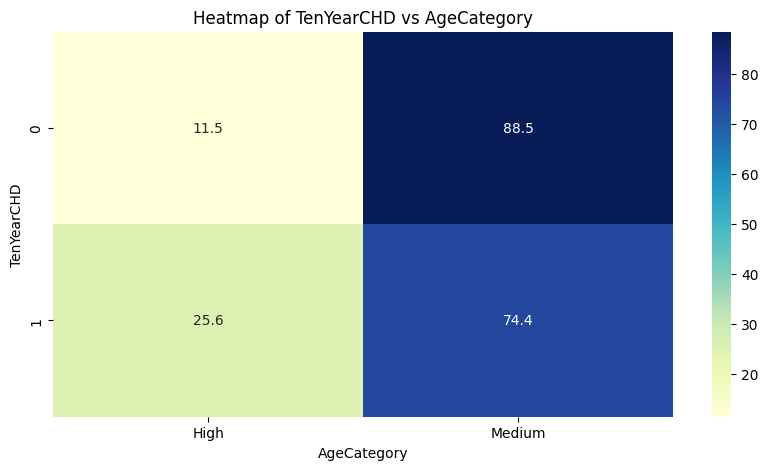

In [62]:
cat_bivariate(eda_df, 'TenYearCHD', 'AgeCategory', normalize=True)

# Now Let's Move Towards The Numerical and Numerical Bivariant Analysis

In [63]:
def num_num_bivariate_plot(df, col1, col2, reg_line=True):
    """
    Bivariate analysis between two numerical columns using scatter plot.
    
    Parameters:
        df (DataFrame): Dataset
        col1 (str): First numerical column
        col2 (str): Second numerical column
        reg_line (bool): Whether to include regression line
    """
    
    print(f"🔍 Bivariate Analysis between '{col1}' and '{col2}'")
    print("=" * 70)
    
    # Calculate correlation
    corr = df[[col1, col2]].corr().iloc[0, 1]
    print(f"📌 Correlation ({col1} vs {col2}): {corr:.4f}\n")
    
    plt.figure(figsize=(8, 5))

    # Scatter plot + regression line (based on user choice)
    if reg_line:
        sns.regplot(
            data=df, 
            x=col1, 
            y=col2, 
            scatter_kws={"alpha": 0.5},
            line_kws={"linewidth": 2}
        )
    else:
        sns.scatterplot(
            data=df,
            x=col1,
            y=col2,
            alpha=0.6
        )
    
    # Titles & labels
    plt.title(f"Scatter Plot: {col1} vs {col2}", fontsize=14)
    plt.xlabel(col1)
    plt.ylabel(col2)
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()

# Conclusions on sysBP and totChol

sysBP vs totChol

- Cloud slightly goes upward
- Trend line rising
- Weak positive correlation (0.20)

Meaning:
People with higher systolic BP tend to have slightly higher cholesterol.
But the relationship is weak, so BP alone cannot predict cholesterol.

🔍 Bivariate Analysis between 'sysBP' and 'totChol'
📌 Correlation (sysBP vs totChol): 0.2087



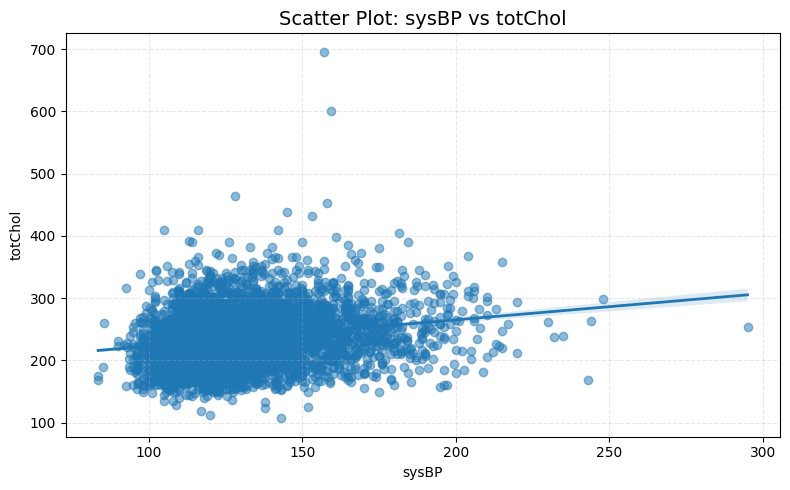

In [64]:
num_num_bivariate_plot(eda_df, "sysBP", "totChol")

# Conclusions on age and BMI

- Points are almost horizontal
- Weak trend
- Correlation only 0.13

Meaning:
Age has very little impact on BMI.
Older people are slightly more likely to have higher BMI, but it's not strong.

🔍 Bivariate Analysis between 'age' and 'BMI'
📌 Correlation (age vs BMI): 0.1361



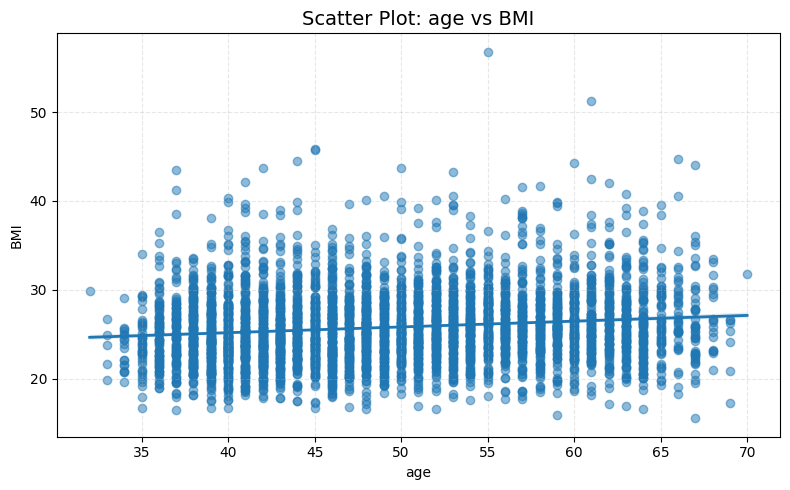

In [65]:
num_num_bivariate_plot(eda_df, "age", "BMI")

# Conclusions on heartRate and glucose

- Points are fully scattered
- No direction
- Correlation 0.09 → extremely weak

Meaning:
heartRate and glucose have almost no relation.
One does not influence the other.

🔍 Bivariate Analysis between 'heartRate' and 'glucose'
📌 Correlation (heartRate vs glucose): 0.0945



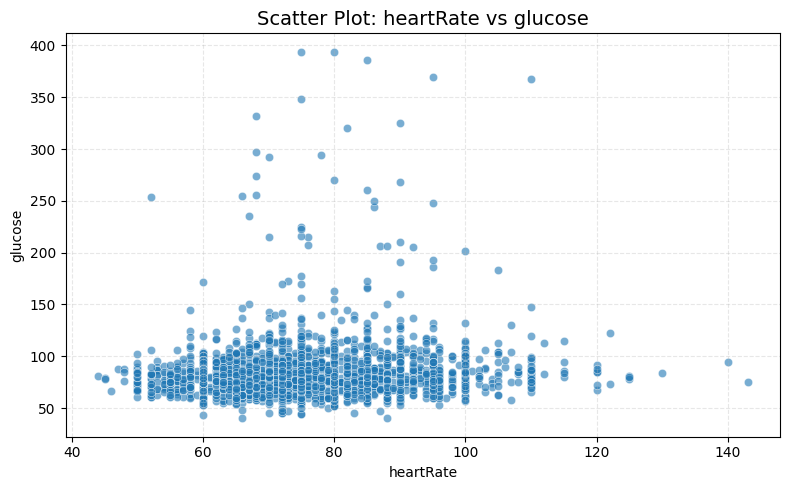

In [66]:
num_num_bivariate_plot(eda_df, "heartRate", "glucose", reg_line=False)

# Now lets move forward towards Multivaruiant Analysis

In [67]:
eda_df

,gender,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD,AgeCategory
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0,Medium
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0,Medium
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0,Medium
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1,High
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0,Medium
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0,Medium
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0,Medium
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0,Medium


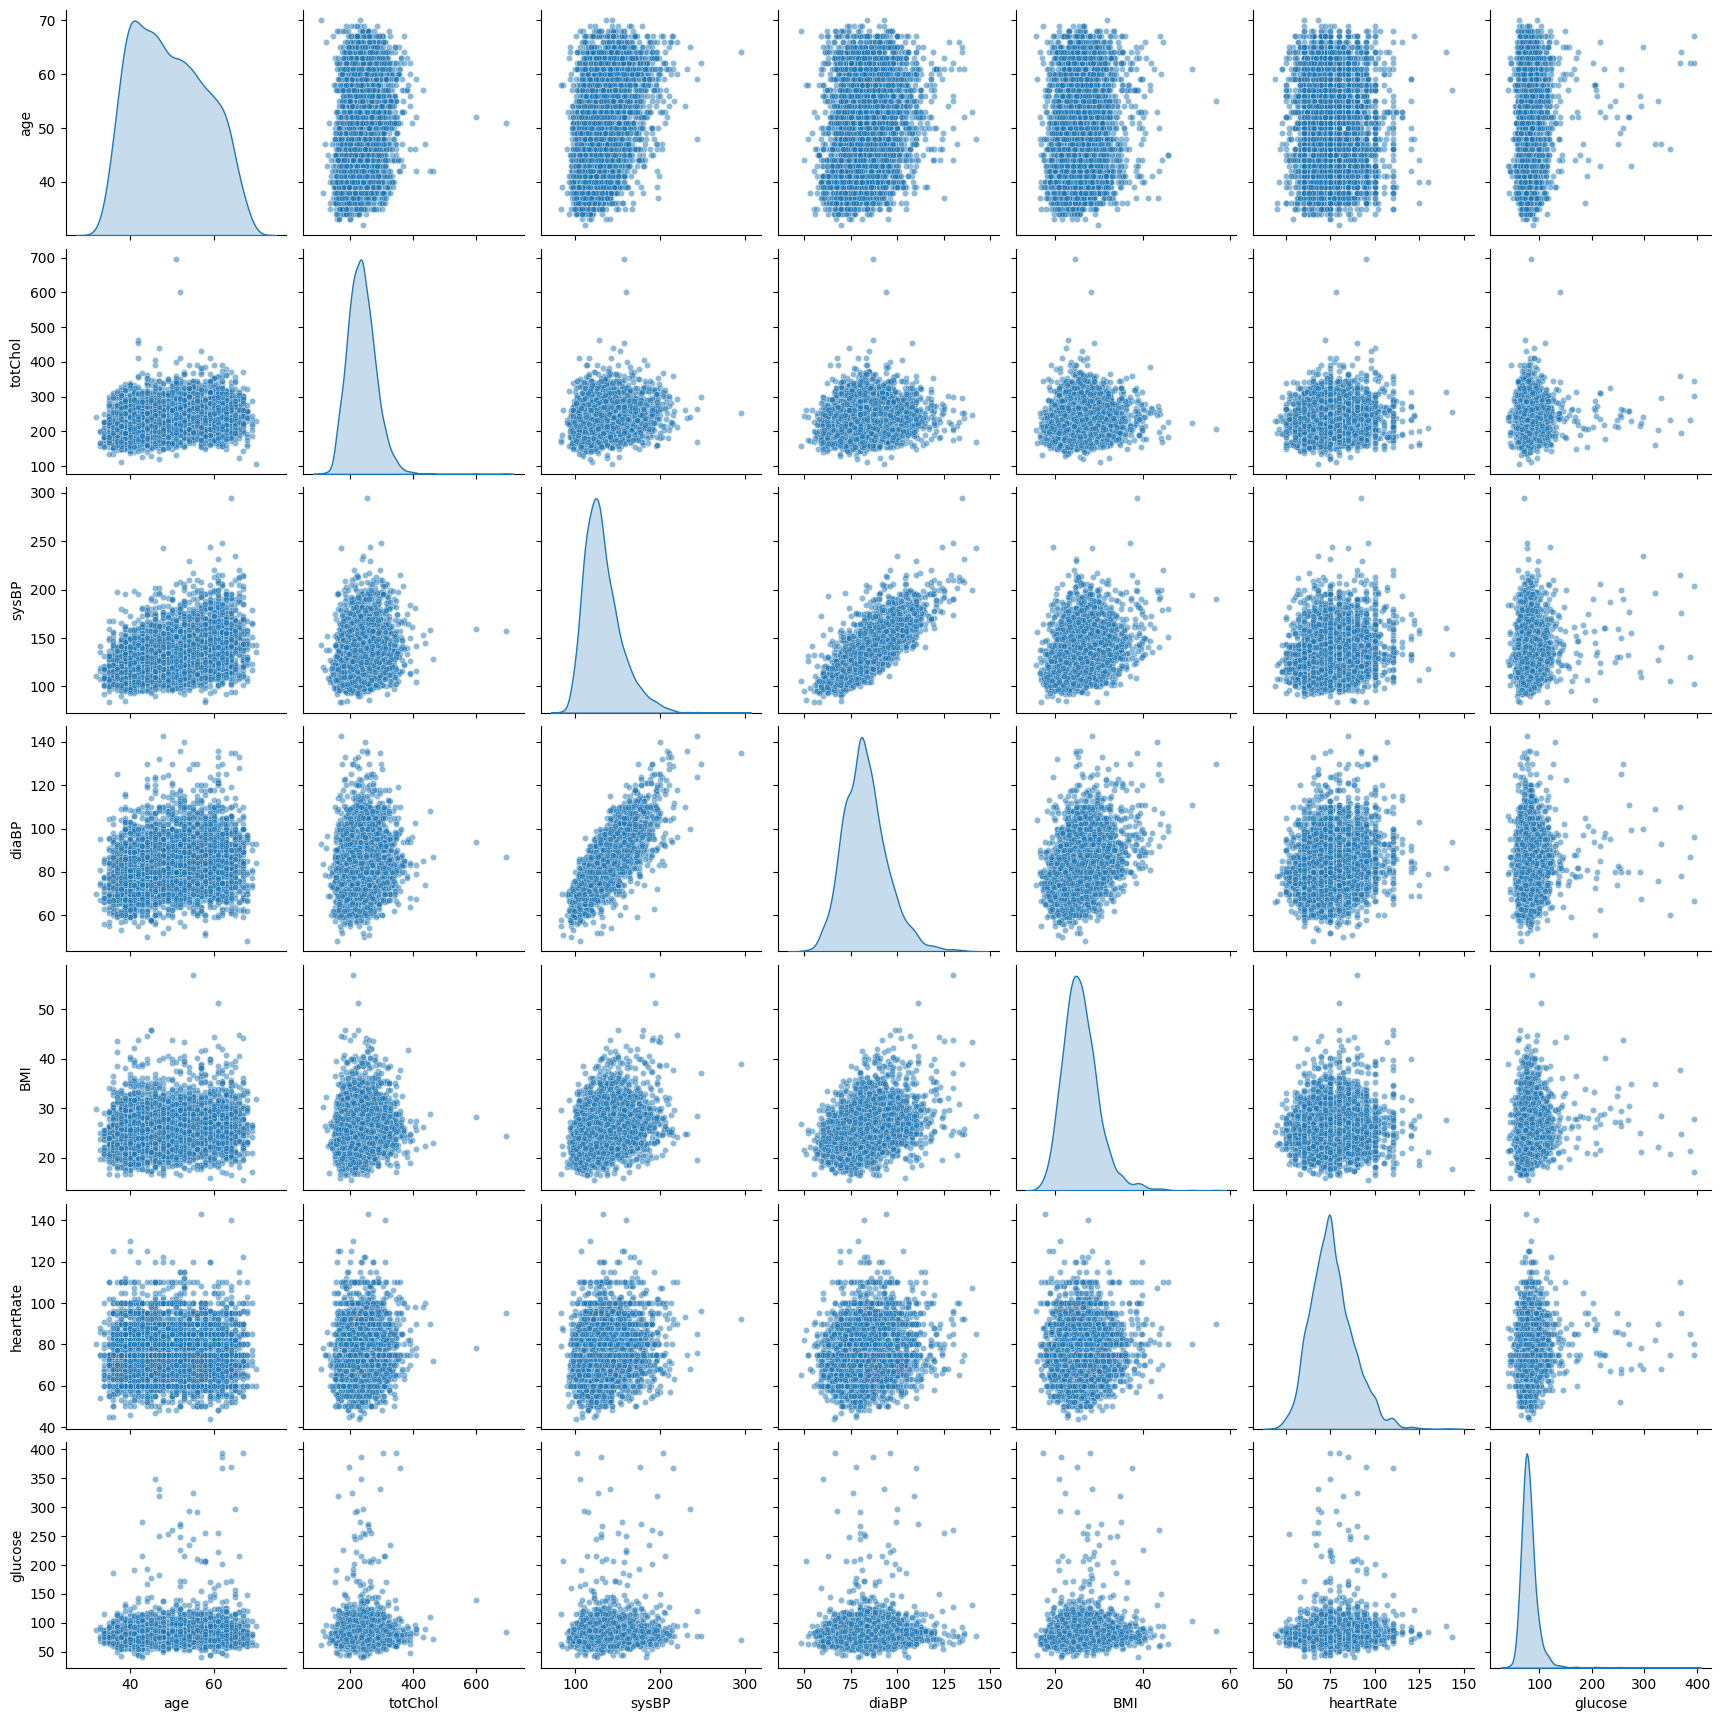

In [68]:
sns.pairplot(eda_df[['age', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']], diag_kind="kde", plot_kws={'alpha':0.5, 's':20})

In [69]:
corr_heatmap = eda_df[['age', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']].corr()

In [70]:
corr_heatmap

,age,totChol,sysBP,diaBP,BMI,heartRate,glucose
age,1.000000,0.262554,0.394053,0.205586,0.136096,-0.012843,0.122356
totChol,0.262554,1.000000,0.208734,0.164698,0.115992,0.091127,0.046538
sysBP,0.394053,0.208734,1.000000,0.783952,0.326906,0.182155,0.140573
diaBP,0.205586,0.164698,0.783952,1.000000,0.377360,0.181021,0.061075
BMI,0.136096,0.115992,0.326906,0.377360,1.000000,0.067451,0.087389
heartRate,-0.012843,0.091127,0.182155,0.181021,0.067451,1.000000,0.094546
glucose,0.122356,0.046538,0.140573,0.061075,0.087389,0.094546,1.000000


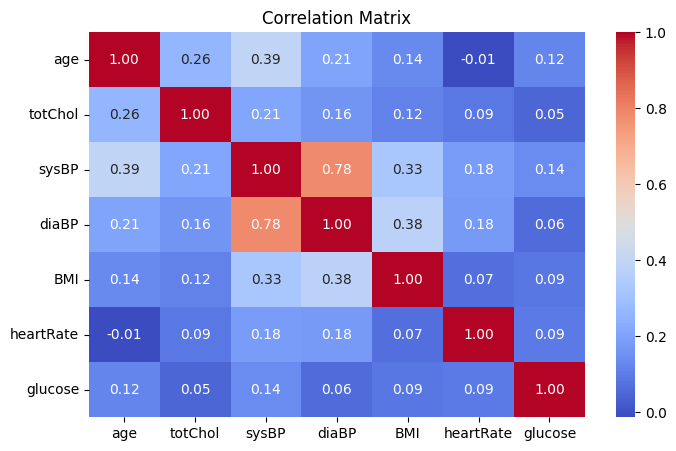

In [71]:
plt.figure(figsize=(8,5))
sns.heatmap(corr_heatmap, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# Model Forming

In [72]:
model_df = df.copy()

In [73]:
model_df

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0


In [74]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, PowerTransformer, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

In [75]:
model_df = model_df.rename(columns={'male': 'gender', 'TenYearCHD': 'CHD'})

In [76]:
model_df

,gender,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,CHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0


In [77]:
model_df = model_df.drop(columns=['education'],axis=1)

In [78]:
model_df

,gender,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,CHD
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,0,48,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0


# Separating InDependent and Dependent features.

In [79]:
X = model_df.drop(columns=['CHD'],axis=1)
Y = model_df['CHD']

# Dividing Data into Train Test Split

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42, stratify=Y
)

# categories Numerical and categorical features.

In [81]:
num_cols = ['age','cigsPerDay','totChol','sysBP','diaBP','BMI','heartRate','glucose']
cat_cols = ['gender','currentSmoker','BPMeds','prevalentStroke','prevalentHyp','diabetes']

# Forming Pipeline for numerical features

In [82]:
num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("yeojohnson", PowerTransformer(method="yeo-johnson")),
    ("scaler", MinMaxScaler())
])

# Forming Pipeline for categorical features.

In [83]:
cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [84]:
preprocessor = ColumnTransformer(transformers=[
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

# Logistic Regression model.

In [85]:
logreg_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=500))
])
logreg_pipe.fit(X_train, y_train)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Random Forest classification

In [86]:
rf_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200))
])
rf_pipe.fit(X_train, y_train)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# XgBoost Model

In [87]:
xgb_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", XGBClassifier(use_label_encoder=False, eval_metric="logloss"))
])
xgb_pipe.fit(X_train, y_train)

c:\Users\Kunal\Desktop\internship\heartpred\heart_env\Lib\site-packages\xgboost\training.py:199: UserWarning: [17:16:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Gradient Boosting

In [88]:
gb_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", GradientBoostingClassifier())
])
gb_pipe.fit(X_train, y_train)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Evaluating All Model.

In [89]:
def evaluate(model, X_test, y_test, name="Model"):
    print("=" * 60)
    print(f"📌 Evaluating: {name}")
    print("=" * 60)

    # Predictions
    y_pred = model.predict(X_test)
    
    # Metrics
    print("✔ Accuracy:", accuracy_score(y_test, y_pred)*100)
    
    print("✔ ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])*100)
    
    print("\n📄 Classification Report:\n", classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("🔢 Confusion Matrix:\n", cm)

    # Visualization
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No CHD", "CHD"], yticklabels=["No CHD", "CHD"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix: {name}")
    plt.tight_layout()
    plt.show()


📌 Evaluating: Logistic Regression
✔ Accuracy: 85.062893081761
✔ ROC-AUC: 70.4706430344735

📄 Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.99      0.92      1079
           1       0.60      0.05      0.09       193

    accuracy                           0.85      1272
   macro avg       0.73      0.52      0.50      1272
weighted avg       0.82      0.85      0.79      1272

🔢 Confusion Matrix:
 [[1073    6]
 [ 184    9]]


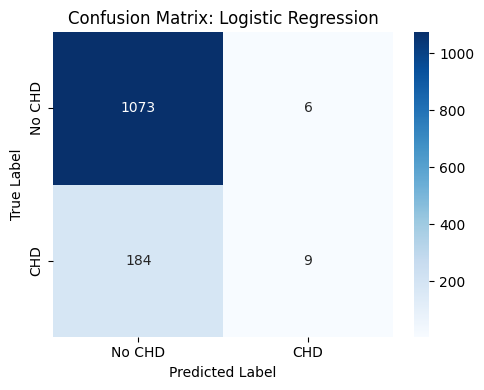

In [90]:
evaluate(logreg_pipe, X_test, y_test, "Logistic Regression")

📌 Evaluating: Random Forest
✔ Accuracy: 84.66981132075472
✔ ROC-AUC: 66.39111247701047

📄 Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.99      0.92      1079
           1       0.47      0.07      0.13       193

    accuracy                           0.85      1272
   macro avg       0.66      0.53      0.52      1272
weighted avg       0.80      0.85      0.80      1272

🔢 Confusion Matrix:
 [[1063   16]
 [ 179   14]]


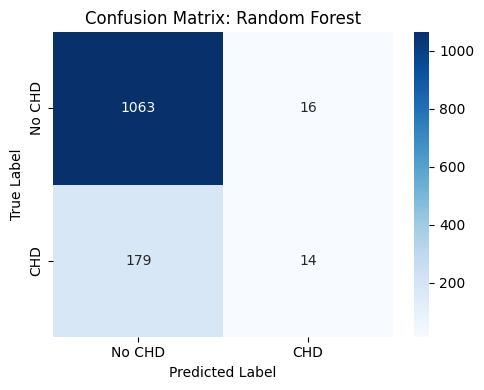

In [91]:
evaluate(rf_pipe, X_test, y_test, "Random Forest")

📌 Evaluating: XGBoost
✔ Accuracy: 82.94025157232704
✔ ROC-AUC: 62.639077633771436

📄 Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.95      0.90      1079
           1       0.34      0.13      0.19       193

    accuracy                           0.83      1272
   macro avg       0.60      0.54      0.55      1272
weighted avg       0.78      0.83      0.80      1272

🔢 Confusion Matrix:
 [[1030   49]
 [ 168   25]]


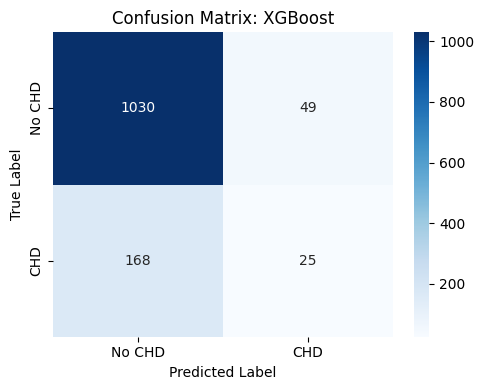

In [92]:
evaluate(xgb_pipe, X_test, y_test, "XGBoost")

📌 Evaluating: XGBoost
✔ Accuracy: 84.5125786163522
✔ ROC-AUC: 67.75535782028072

📄 Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.98      0.91      1079
           1       0.45      0.09      0.15       193

    accuracy                           0.85      1272
   macro avg       0.65      0.53      0.53      1272
weighted avg       0.80      0.85      0.80      1272

🔢 Confusion Matrix:
 [[1058   21]
 [ 176   17]]


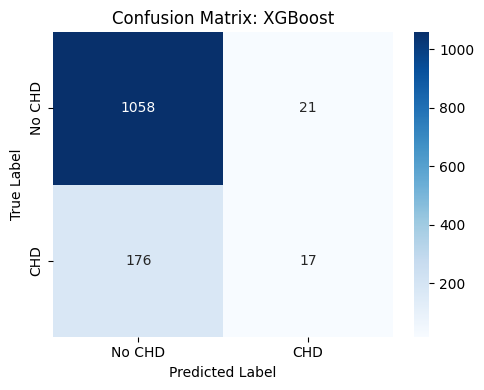

In [93]:
evaluate(gb_pipe, X_test, y_test, "XGBoost")

# prediction on sample Data

In [94]:
sample_data = {
    "gender":1, "age":50, "currentSmoker":1, "cigsPerDay":1,
    "BPMeds":0, "prevalentStroke":0, "prevalentHyp":1, "diabetes":0,
    "totChol":313, "sysBP":179, "diaBP":92, "BMI":25.97,
    "heartRate":66, "glucose":86
}

sample_data = pd.DataFrame([sample_data])

lgpred = logreg_pipe.predict(sample_data)
rfpred = rf_pipe.predict(sample_data)
xgpred = xgb_pipe.predict(sample_data)
gbpred = gb_pipe.predict(sample_data)

In [95]:
print("Logisticprediction :",lgpred)
print("RandomForestprediction :",rfpred)
print("XgBoostprediction :",xgpred)
print("GradientBoostingprediction :",gbpred)

Logisticprediction : [0]
RandomForestprediction : [0]
XgBoostprediction : [0]
GradientBoostingprediction : [0]


# Use SMOTE inside train set only.

- SMOTE ka kaam sirf training ke waqt data balance karna hai.
- Real user ke data ko SMOTE se modify nahi karna chahiye.
- SMOTE ek row par kaam nahi karta, isliye prediction pipeline me rakhna galat hai.
    - ek single patient ka data hota hai
    - 1 row hoti hai

    - Ab SMOTE kya try karega?

    “I want to generate synthetic samples by interpolating nearest neighbors.”

    But...

    ❌ Nearest neighbor ke liye at least 2 rows chahiye
    ❌ SMOTE 1 row par run hi nahi kar sakta

    Result:
    error
    pipeline crash
    prediction fail
    FastAPI/Streamlit app crash
    
- Isliye hamesha trained model ko SMOTE ke bina deploy karte hain.

In [96]:
smote_df = df.copy()

In [97]:
smote_df

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,0,48,2.0,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1.0,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,2.0,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,3.0,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0


In [98]:
smote_df = smote_df.drop(columns=['education'],axis=1)

In [99]:
smote_df = smote_df.rename(columns={"male" : "gender", 'TenYearCHD':'CHD'})

In [100]:
smote_df

,gender,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,CHD
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,0,48,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0,0
4236,0,44,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN,0
4237,0,52,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0,0
4238,1,40,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0,0


In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PowerTransformer, MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

In [102]:
X1 = smote_df.drop("CHD", axis=1)
y1 = smote_df["CHD"]

X_train, X_test, y_train, y_test = train_test_split(
    X1, y1, test_size=0.30, random_state=42, stratify=y1
)

In [103]:
X1

,gender,age,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose
0,1,39,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0
1,0,46,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0
2,1,48,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0
3,0,61,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0
4,0,46,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4235,0,48,1,20.0,NaN,0,0,0,248.0,131.0,72.0,22.00,84.0,86.0
4236,0,44,1,15.0,0.0,0,0,0,210.0,126.5,87.0,19.16,86.0,NaN
4237,0,52,0,0.0,0.0,0,0,0,269.0,133.5,83.0,21.47,80.0,107.0
4238,1,40,0,0.0,0.0,0,1,0,185.0,141.0,98.0,25.60,67.0,72.0


In [104]:
num_cols = ['age','cigsPerDay','totChol','sysBP','diaBP','BMI','heartRate','glucose']
cat_cols = ['gender','currentSmoker','prevalentStroke','prevalentHyp','diabetes','BPMeds']

In [105]:
num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("yeojohnson", PowerTransformer(method="yeo-johnson")),
    ("scaler", MinMaxScaler())
])

cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [106]:
preprocessor = ColumnTransformer(transformers=[
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

In [107]:
logreg_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=500, class_weight='balanced'))
])

In [108]:
rf_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=42
    ))
])

In [109]:
xgb_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=3,
        eval_metric="logloss"
    ))
])

In [110]:
gb_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3
    ))
])

In [111]:
models = {
    "Logistic Regression": logreg_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline,
    "Gradient Boosting": gb_pipeline,
}

for name, model in models.items():
    print(f"🚀 Training {name}...")
    model.fit(X_train, y_train)


🚀 Training Logistic Regression...
🚀 Training Random Forest...
🚀 Training XGBoost...
🚀 Training Gradient Boosting...


In [112]:
def evaluate_model(model, name):
    print("="*65)
    print(f"📌 Evaluating: {name}")
    print("="*65)

    # Predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Basic metrics
    print(f"✔ Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("\n📄 Classification Report:\n")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("🔢 Confusion Matrix:\n", cm)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No CHD", "CHD"],
                yticklabels=["No CHD", "CHD"])
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

    # =============================
    # 🚀 ROC Curve
    # =============================
    print(f"✔ ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
    
    fpr, tpr, thresholds = roc_curve(y_test, y_proba)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.4f}", linewidth=2)
    plt.plot([0,1], [0,1], "k--", label="Random Guess")
    
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.grid(True)
    plt.show()

📌 Evaluating: Logistic Regression
✔ Accuracy: 0.6627

📄 Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.67      0.77      1079
           1       0.25      0.62      0.36       193

    accuracy                           0.66      1272
   macro avg       0.58      0.65      0.56      1272
weighted avg       0.81      0.66      0.71      1272

🔢 Confusion Matrix:
 [[723 356]
 [ 73 120]]


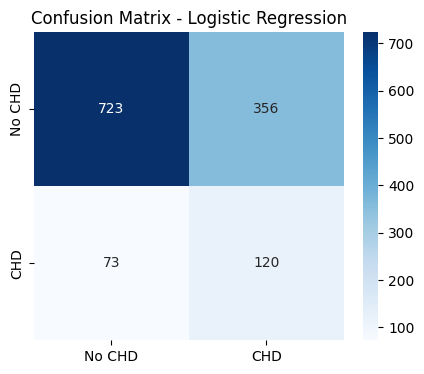

✔ ROC-AUC: 0.6962


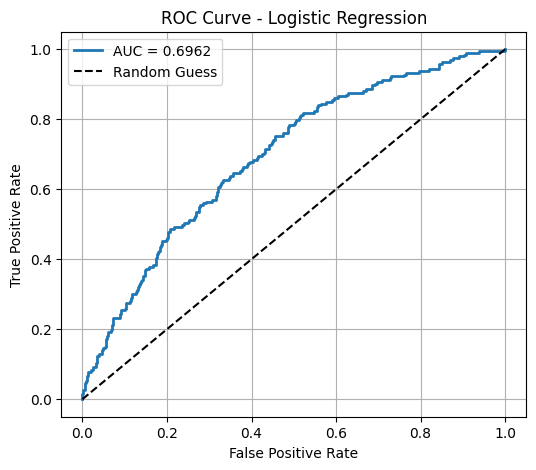

📌 Evaluating: Random Forest
✔ Accuracy: 0.7877

📄 Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.88      0.88      1079
           1       0.28      0.26      0.27       193

    accuracy                           0.79      1272
   macro avg       0.58      0.57      0.57      1272
weighted avg       0.78      0.79      0.78      1272

🔢 Confusion Matrix:
 [[952 127]
 [143  50]]


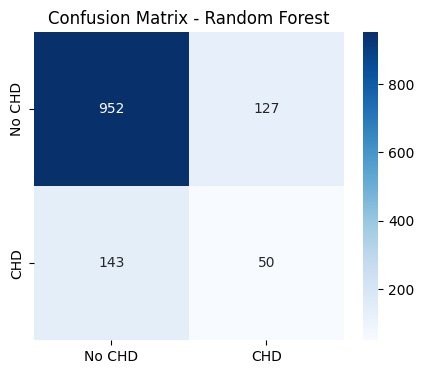

✔ ROC-AUC: 0.6633


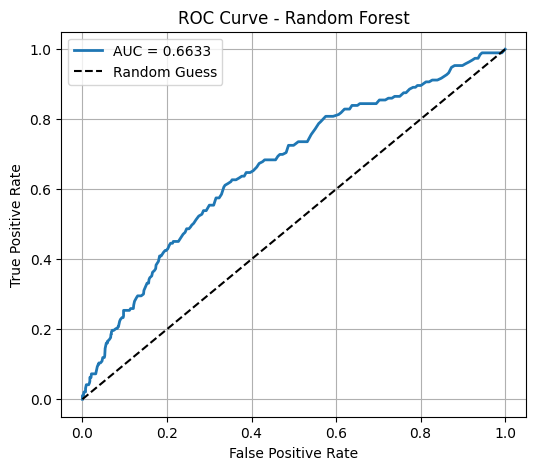

📌 Evaluating: XGBoost
✔ Accuracy: 0.6164

📄 Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.63      0.74      1079
           1       0.21      0.55      0.30       193

    accuracy                           0.62      1272
   macro avg       0.55      0.59      0.52      1272
weighted avg       0.78      0.62      0.67      1272

🔢 Confusion Matrix:
 [[677 402]
 [ 86 107]]


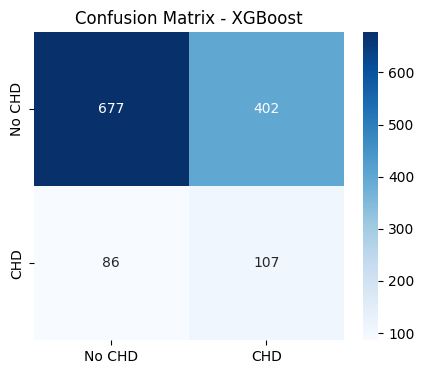

✔ ROC-AUC: 0.6422


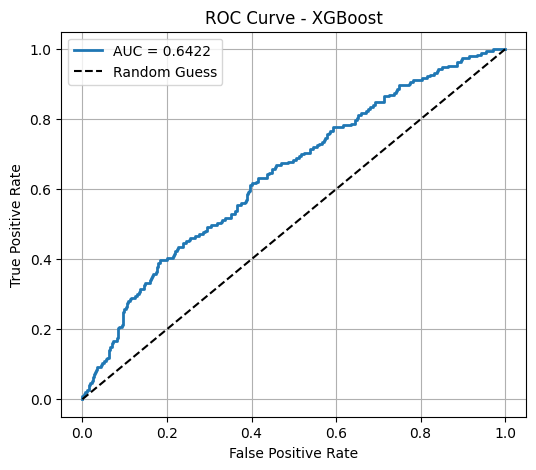

📌 Evaluating: Gradient Boosting
✔ Accuracy: 0.7634

📄 Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.84      0.86      1079
           1       0.28      0.36      0.31       193

    accuracy                           0.76      1272
   macro avg       0.58      0.60      0.59      1272
weighted avg       0.79      0.76      0.77      1272

🔢 Confusion Matrix:
 [[902 177]
 [124  69]]


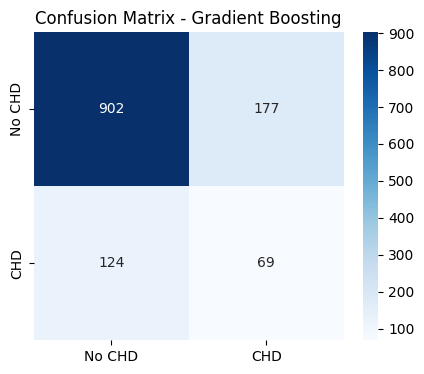

✔ ROC-AUC: 0.6492


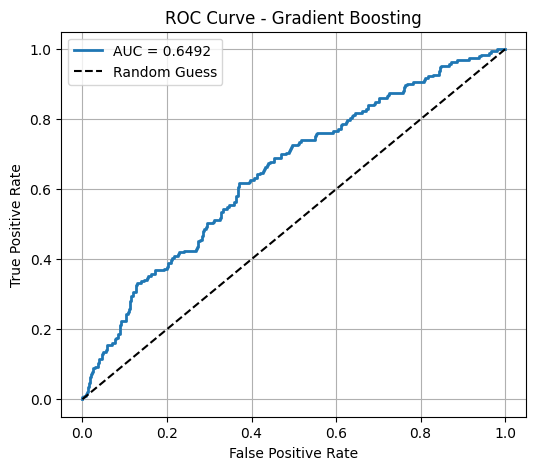

In [113]:
for name, model in models.items():
    evaluate_model(model, name)

# Prediction on sample data

In [114]:
sample_data = {
    "gender":1, "age":50, "currentSmoker":1, "cigsPerDay":35,
    "BPMeds":1, "prevalentStroke":1, "prevalentHyp":1, "diabetes":1,
    "totChol":420, "sysBP":179, "diaBP":92, "BMI":25.97,
    "heartRate":66, "glucose":112
}

sample_data = pd.DataFrame([sample_data])

lgpred = logreg_pipe.predict(sample_data)
rfpred = rf_pipe.predict(sample_data)
xgpred = xgb_pipe.predict(sample_data)
gbpred = gb_pipe.predict(sample_data)

In [115]:
print("Logisticprediction :",lgpred)
print("RandomForestprediction :",rfpred)
print("XgBoostprediction :",xgpred)
print("GradientBoostingprediction :",gbpred)

Logisticprediction : [1]
RandomForestprediction : [1]
XgBoostprediction : [1]
GradientBoostingprediction : [1]


# Pandas Profiling
- you encounterd an error you need to install this :- pip install ipywidgets


In [116]:
from ydata_profiling import ProfileReport

In [118]:
profile = ProfileReport(smote_df, title="SMOTE Dataset Profiling Report", explorative=True)
profile.to_file("smotedf_profile.html")
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 15/15 [00:00<00:00, 71.73it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]